In [559]:
import numpy as np
import pandas as pd
import glob as glob
import os as os
import statsmodels.api as sm 
from statsmodels.stats.outliers_influence import variance_inflation_factor

# plotting
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import seaborn as sns

#Time Series
import statsmodels.tsa as tsa
from statsmodels.graphics.tsaplots import month_plot

#Functions
from sklearn.model_selection import train_test_split

#Regression
from sklearn.linear_model import Lasso, Ridge
from sklearn.linear_model import LinearRegression
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

### Introduction

This notebook began as dedicated notebook but has evolved into the main notebook and aggreagtes or will aggregate all dataframes. <br>
<br>
Nekton are the creature that live and swim in the open water column, including fish, seaturtles, etc and are an important representation of ecosystem heaklth. Nekton specific data provided here include:
- Standardized frequency of sampling
- Water Quality, presence of artificual compounds, species catch and counts
> This permit calculation of **Species Richness and Species Abundance**, in addition to a pre-calculated SDI (Shannon Diversity Index)
 
> Introduction of data from other notebooks are described at the time of introduction




### Read-in Main Data & Data Cleaning

#### Dummies

In [2]:
pwd

'J:\\Brainstation\\Capstone Git\\Apollo_Beach_Model - Copy\\notebooks'

In [3]:
os.chdir('J:\\Brainstation\\Capstone Git\\data\\PossibleDataSources\\Benthic Index\\OG_Results')
os.listdir()

['Benthic_BioDataSpreadsheet_ActualValuesCommunityStats2.csv',
 'Benthic_BioDataSpreadsheet_AdjustedValues.csv',
 'Benthic_BioHydrology.csv',
 'Benthic_BiologyListCorrected.csv',
 'Benthic_BioSampleCollectionInfo.csv',
 'Benthic_SedimentChemistryList.csv',
 'Benthic_SedimentChemistrySpreadsheet.csv',
 'Benthic_SiltClay.csv']

In [4]:
# Read BENTHIC biodata spreadsheet
# Includes cleaned data: Shannon Diversity Index
benX = pd.read_csv('Benthic_BioDataSpreadsheet_AdjustedValues.csv',encoding='cp1252', low_memory=False)

In [5]:
 os.chdir('J:\\Brainstation\\Capstone Git\\data\\PossibleDataSources\\nekton')

In [6]:
dir_list=os.listdir()

In [7]:
catch_sel=pd.read_csv('tbm_catch_selfactors.csv')

In [8]:
benX.SampleTime=pd.to_datetime(benX.SampleTime,format='mixed')
benX

,ProgramName,FundingProject,AreaAbbr,AreaName,Hexagon,Year,SampleTime,StationID,StationNumber,Latitude,Longitude,Temp-T,TempQ-T,Temp-B,TempQ-B,DO-T,DOQ-T,DO-B,DOQ-B,DOp-T,DOp-B,Cond-T,CondQ-T,Cond-B,CondQ-B,pH-T,pHQ-T,pH-B,pHQ-B,Sal-T,SalQ-T,Sal-B,SalQ-B,Salinity-BCat,Transmitter ID Number,Display ID Number,Depth-T,DepthQ-T,Depth-B,DepthQ-B,Depth-BCat,SiltClayPercent,SiltClay_Q,SiltClayCat,OrganicsCollected,A_BHC,A_BHC_Q,B_BHC,B_BHC_Q,D_BHC,D_BHC_Q,G_BHC,G_BHC_Q,G_BHC_PEL,Aldrin,Aldrin_Q,Dieldrin,Dieldrin_Q,Dieldrin_PEL,Endrin,Endrin_Q,Endosulfan_I,Endosulfan_I_Q,Endosulfan_II,Endosulfan_II_Q,Heptachlor,Heptachlor_Q,Heptachlor_Epoxide,Heptachlor_Epoxide_Q,DDD,DDD_Q,DDT_PEL,DDE,DDE_Q,DDE_PEL,DDT,DDT_Q,DDT_PEL.1,Total_DDT,Endrin_Aldehyde,Endrin_Aldehyde_Q,Endosulfan_SO4,Endosulfan_SO4_Q,Methoxychlor,Methoxychlor_Q,Endrin_Ketone,Endrin_Ketone_Q,Mirex,Mirex_Q,A_Chlordane,A_Chlordane_Q,G_Chlordane,G_Chlordane_Q,Total_Chlordane,Total_Chlordane_Q,Total_Chlordane_PEL,PCB_8,PCB_8_Q,PCB_18,PCB_18_Q,PCB_28,PCB_28_Q,PCB_44,PCB_44_Q,PCB_52,PCB_52_Q,PCB_66,PCB_66_Q,PCB_101,PCB_101_Q,PCB_105,PCB_105_Q,PCB_118,PCB_118_Q,PCB_128,PCB_128_Q,PCB_153,PCB_153_Q,PCB_170,PCB_170_Q,PCB_180,PCB_180_Q,PCB_187,PCB_187_Q,PCB_195,PCB_195_Q,PCB_206,PCB_206_Q,PCB_1016,PCB_1016_Q,PCB_1221,PCB_1221_Q,PCB_1232,PCB_1232_Q,PCB_1242,PCB_1242_Q,PCB_1248,PCB_1248_Q,PCB_1254,PCB_1254_Q,PCB_1260,PCB_1260_Q,PCB_1262,PCB_1262_Q,PCB_1268,PCB_1268_Q,Total_PCB,Total_PCB_PEL,Acenaphthene,Acenaphthene_Q,Acenaphthene_PEL,Acenaphthylene,Acenaphthylene_Q,Acenaphthylene_PEL,Anthracene,Anthracene_Q,Anthracene_PEL,Fluorene,Fluorene_Q,Fluorene_PEL,Naphthalene,Naphthalene_Q,Naphthalene_PEL,Phenanthrene,Phenanthrene_Q,Phenanthrene_PEL,Total_LMW_PAH,Total_LMW_PAH_PEL,Benzo(a)anthracene,Benzo(a)anthracene_Q,Benzo(a)anthracene_PEL,Benzo(a)pyrene,Benzo(a)pyrene_Q,Chrysene,Chrysene_Q,"Dibenzo(a,h)anthracene","Dibenzo(a,h)anthracene_Q",Fluoranthene,Fluoranthene_Q,Pyrene,Pyrene_Q,Pyrene_PEL,Total_HMW_PAH,Total_HMW_PAH_PEL,Total_PAHs,Total_PAHs_PEL,Benzo(b)fluoranthene,Benzo(b)fluoranthene_Q,Benzo(k)fluoranthene,Benzo(k)fluoranthene_Q,"Indeno(1,2,3-c,d)pyrene","Indeno(1,2,3-c,d)pyrene_Q","Benzo(g,h,i)perylene","Benzo(g,h,i)perylene_Q",Retene,Retene_Q,Coronene,Coronene_Q,MetalsCollected,Aluminum,Aluminum_Q,Antimony,Antimony_Q,Arsenic,Arsenic_Q,Arsenic_PEL,Cadmium,Cadmium_Q,Cadmium_PEL,Chromium,Chromium_Q,Chromium_PEL,Copper,Copper_Q,Copper_PEL,Iron,Iron_Q,Lead,Lead_Q,Lead_PEL,Manganese,Manganese_Q,Nickel,Nickel_Q,Nickel_PEL,Selenium,Selenium_Q,Silver,Silver_Q,Silver_PEL,Tin,Tin_Q,Zinc,Zinc_Q,Zinc_PEL,Mercury,Mercury_Q,Mercury_PEL,TOC,TOC_Q,Total_Carbon,Total_Carbon_Q,Inorganic_Carbon,Inorganic_Carbon_Q,GeoMean_PEL_Ratio,TBBI,TBBICat,SpeciesRichness,AdjCountAbundance,ShannonDiversity,DomSpecies1,DomSpecies1RelAbund,DomSpecies2,DomSpecies2RelAbund
0,Benthic Monitoring,TBEP ...,HB,Hillsborough Bay,HB34,1993,1993-09-14 11:33:00,2452,93HB03,27.874001,-82.418999,29.31,NaN,29.30,NaN,6.39,NaN,5.42,NaN,95.0,80.7,NaN,NaN,NaN,NaN,7.88,NaN,7.85,NaN,23.40,NaN,23.70,NaN,Polyhaline,NaN,NaN,0.1,NaN,3.00,NaN,Deep Subtidal,NaN,O,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.84,Degraded,8.0,275.0,0.66,Paraprionospio sp.,0.272727,Sigambra tentaculata,0.181818
1,Be

In [9]:
pwd

'J:\\Brainstation\\Capstone Git\\data\\PossibleDataSources\\nekton'

In [10]:
dir_list

['.ipynb_checkpoints',
 '.RData',
 '.Rhistory',
 'nekton_fimsgdat.csv',
 'nekton_phy_tbni_sgrs.csv',
 'nekton_species_codes.csv',
 'nekton_tbm_c.csv',
 'nekton_tbm_c.xlsx',
 'species_codes.sas7bdat',
 'species_code_changes.sas7bdat',
 'tbm_catch_selfactors.csv',
 'tbm_catch_wfactors.csv',
 'tbm_combined_catch_env_factors.csv',
 'tbm_environment_wfactors.csv',
 'tbm_env_factors.csv',
 'tbm_l.csv',
 'tbniscr.RData',
 'Untitled.ipynb',
 'wq-dash']

In [11]:
catch_sel

,Reference,Aca_quadricornis,Ach_lineatus,Achiridae_spp,Adi_xenica,Aet_narinari,Albula_spp,Alu_schoepfii,Ana_criniger,Anc_cubana,Anc_hepsetus,Anc_lyolepis,Anc_mitchilli,Anchoa_spp,Arc_probatocephalus,Argopecten_spp,Ari_felis,Ast_y_graecum,Bag_marinus,Bai_chrysoura,Bat_soporator,Bathygobius_spp,Brevoortia_spp,Cal_arctifrons,Cal_ornatus,Cal_penna,Cal_sapidus,Cal_similis,Calamus_spp,Callinectes_spp,Car_hippos,Car_leucas,Car_limbatus,Cen_striata,Cen_undecimalis,Cha_faber,Cha_saburrae,Chi_schoepfii,Chl_chrysurus,Cit_macrops,Clupeidae_spp,Cte_boleosoma,Cte_smaragdus,Cyn_arenarius,Cyn_nebulosus,Cyp_variegatus,Dac_moorei,Dactyloscopidae_spp,Das_americana,Das_sabina,Das_say,Dia_auratus,Diapterus_spp,Dip_formosum,Dip_holbrookii,Dor_petenense,Ech_neucratoides,Elo_saurus,Elo_smithi,Elopiformes_spp,Etr_crossotus,Euc_argenteus,Euc_gula,Euc_harengulus,Eucinostomus_spp,Eug_plumieri,Far_duorarum,Flo_carpio,Fun_confluentus,Fun_grandis,Fun_similis,Gob_bosc,Gob_longipala,Gob_robustum,Gob_strumosus,Gobiosoma_spp,Gym_micrura,Hae_aurolineatum,Hae_plumierii,Har_jaguana,Hem_balao,Hemiramphidae_spp,Hemiramphus_spp,Hip_erectus,Hip_zosterae,Hippocampus_spp,Hyp_hentz,Hyp_meeki,Hyp_unifasciatus,Hyporhamphus_spp,Lactophrys_spp,Lag_rhomboides,Lei_xanthurus,Lep_osseus,Lim_polyphemus,Lop_cyprinoides,Luc_parva,Lut_analis,Lut_griseus,Lut_synagris,Mem_martinica,Men_americanus,Men_saxatilis,Menidia_spp,Menippe_spp,Menticirrhus_spp,Mic_gulosus,Mic_thalassinus,Mic_undulatus,Mon_ciliatus,Mug_cephalus,Mug_curema,Mug_trichodon,Mugil_spp,Myc_microlepis,Myr_punctatus,Nic_usta,Ogc_cubifrons,Oli_saurus,Opi_oglinum,Ops_beta,Ore_aureus,Oreo_Saroth_spp,Ort_chrysoptera,Ostraciidae_spp,Par_albigutta,Par_marmoratus,Penaeidae_spp,Pep_paru,Poe_latipinna,Pog_cromis,Pom_saltatrix,Portunus_spp,Pri_scitulus,Pri_tribulus,Rhi_bonasus,Rim_constrictus,Rimapenaeus_spp,Sar_aurita,Sar_melanotheron,Sci_ocellatus,Sciaenidae_spp,Sco_brasiliensis,Sco_maculatus,Sel_vomer,Sph_barracuda,Sph_borealis,Sph_nephelus,Sph_spengleri,Sph_tiburo,Sphoeroides_spp,Ste_hispidus,Ste_setifer,Str_marina,Str_notata,Str_timucu,Strongylura_spp,Sym_plagiusa,Syn_floridae,Syn_foetens,Syn_louisianae,Syn_scovelli,Syngnathidae_spp,Synodontidae_spp,Tra_carolinus,Tra_falcatus,Tri_maculatus,Tyl_crocodilus,Uro_floridana,Season,TBEP_seg,sgyear,FLUCCSCODE,areas,DominantVeg
0,TBM1998010906,0,0,0,0,0,0,0,0,0,0,0,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Winter,OTB,1999,NaN,22,NaN
1,TBM1998010910,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Winter,OTB,1999,NaN,21,NaN
2,TBM1998010912,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Winter,OTB,1999,NaN,21,NaN
3,TBM1998010914,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,Winter,OTB,1999,NaN,21,Halodule spp.
4,TBM1998010915,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,

In [12]:
catch_sel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4575 entries, 0 to 4574
Columns: 175 entries, Reference to DominantVeg
dtypes: float64(6), int64(165), object(4)
memory usage: 6.1+ MB


In [13]:
catch_sel.Season.unique()

array(['Winter', 'Spring', 'Summer', 'Fall'], dtype=object)

In [14]:
catch_sel['season_conv']=catch_sel.Season.map({'Spring':1,'Summer':2,'Fall':3,'Winter':4})
catch_sel.season_conv

0       4
1       4
2       4
3       4
4       4
       ..
4570    4
4571    4
4572    4
4573    4
4574    4
Name: season_conv, Length: 4575, dtype: int64

In [15]:
catch_sel.DominantVeg.fillna(0)

0                      0
1                      0
2                      0
3          Halodule spp.
4                      0
              ...       
4570                   0
4571       Halodule spp.
4572      Thalassia spp.
4573    Syringodium spp.
4574                 SAV
Name: DominantVeg, Length: 4575, dtype: object

##### Veg Dummies

In [560]:
#### Need to format data for regression

In [16]:
veg_dummies=pd.get_dummies(catch_sel.DominantVeg)

In [17]:
# Start creating dummies for veg
veg_dummies.columns.str.contains('halophila')

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False])

In [18]:
for col in veg_dummies.columns:
    veg_dummies.rename(columns={col:'v_'+ col.lower().replace(" ","_")},inplace=True)
veg_dummies

,v_algae,v_algae:_filamentous_green,v_algae:_filamentous_red,v_caulerpa_spp.,v_gracillaria,v_halodule_spp.,v_halophila_decipiens_(paddle_grass),v_halophila_engelmanii__(star_grass),v_halophila_spp.,v_ruppia_spp.,v_sav,v_savalg,v_sargassum_spp,v_seagrasses:_mixed,v_seagrasses:_unidentified,v_syringodium_spp.,v_thalassia_spp.
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4570,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4571,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
4572,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4573,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [19]:
# Chose halophila as column to combine for dummies
# Get columns


In [20]:
#Combine 'halophila' columns
veg_dummies.iloc[:,8]=veg_dummies.iloc[:,8]+veg_dummies.iloc[:,7]+veg_dummies.iloc[:,6]

In [21]:
# Drop combined dummy columns
veg_dummies.drop(columns=['v_halophila_decipiens_(paddle_grass)', 'v_halophila_engelmanii__(star_grass)'],inplace=True)

In [22]:
veg_dummies

,v_algae,v_algae:_filamentous_green,v_algae:_filamentous_red,v_caulerpa_spp.,v_gracillaria,v_halodule_spp.,v_halophila_spp.,v_ruppia_spp.,v_sav,v_savalg,v_sargassum_spp,v_seagrasses:_mixed,v_seagrasses:_unidentified,v_syringodium_spp.,v_thalassia_spp.
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4570,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4571,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
4572,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4573,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


##### segment dummies

In [23]:
segment_dummies=pd.get_dummies(catch_sel.TBEP_seg)

In [24]:
catch_sel.Season.value_counts()

Season
Summer    1535
Winter    1526
Fall       774
Spring     740
Name: count, dtype: int64

#### Formatting & Cleaning of Main DF (Species Catch data)

In [25]:
catch_sel[catch_sel.Reference.str.slice(-4).str.startswith('09')]

,Reference,Aca_quadricornis,Ach_lineatus,Achiridae_spp,Adi_xenica,Aet_narinari,Albula_spp,Alu_schoepfii,Ana_criniger,Anc_cubana,Anc_hepsetus,Anc_lyolepis,Anc_mitchilli,Anchoa_spp,Arc_probatocephalus,Argopecten_spp,Ari_felis,Ast_y_graecum,Bag_marinus,Bai_chrysoura,Bat_soporator,Bathygobius_spp,Brevoortia_spp,Cal_arctifrons,Cal_ornatus,Cal_penna,Cal_sapidus,Cal_similis,Calamus_spp,Callinectes_spp,Car_hippos,Car_leucas,Car_limbatus,Cen_striata,Cen_undecimalis,Cha_faber,Cha_saburrae,Chi_schoepfii,Chl_chrysurus,Cit_macrops,Clupeidae_spp,Cte_boleosoma,Cte_smaragdus,Cyn_arenarius,Cyn_nebulosus,Cyp_variegatus,Dac_moorei,Dactyloscopidae_spp,Das_americana,Das_sabina,Das_say,Dia_auratus,Diapterus_spp,Dip_formosum,Dip_holbrookii,Dor_petenense,Ech_neucratoides,Elo_saurus,Elo_smithi,Elopiformes_spp,Etr_crossotus,Euc_argenteus,Euc_gula,Euc_harengulus,Eucinostomus_spp,Eug_plumieri,Far_duorarum,Flo_carpio,Fun_confluentus,Fun_grandis,Fun_similis,Gob_bosc,Gob_longipala,Gob_robustum,Gob_strumosus,Gobiosoma_spp,Gym_micrura,Hae_aurolineatum,Hae_plumierii,Har_jaguana,Hem_balao,Hemiramphidae_spp,Hemiramphus_spp,Hip_erectus,Hip_zosterae,Hippocampus_spp,Hyp_hentz,Hyp_meeki,Hyp_unifasciatus,Hyporhamphus_spp,Lactophrys_spp,Lag_rhomboides,Lei_xanthurus,Lep_osseus,Lim_polyphemus,Lop_cyprinoides,Luc_parva,Lut_analis,Lut_griseus,Lut_synagris,Mem_martinica,Men_americanus,Men_saxatilis,Menidia_spp,Menippe_spp,Menticirrhus_spp,Mic_gulosus,Mic_thalassinus,Mic_undulatus,Mon_ciliatus,Mug_cephalus,Mug_curema,Mug_trichodon,Mugil_spp,Myc_microlepis,Myr_punctatus,Nic_usta,Ogc_cubifrons,Oli_saurus,Opi_oglinum,Ops_beta,Ore_aureus,Oreo_Saroth_spp,Ort_chrysoptera,Ostraciidae_spp,Par_albigutta,Par_marmoratus,Penaeidae_spp,Pep_paru,Poe_latipinna,Pog_cromis,Pom_saltatrix,Portunus_spp,Pri_scitulus,Pri_tribulus,Rhi_bonasus,Rim_constrictus,Rimapenaeus_spp,Sar_aurita,Sar_melanotheron,Sci_ocellatus,Sciaenidae_spp,Sco_brasiliensis,Sco_maculatus,Sel_vomer,Sph_barracuda,Sph_borealis,Sph_nephelus,Sph_spengleri,Sph_tiburo,Sphoeroides_spp,Ste_hispidus,Ste_setifer,Str_marina,Str_notata,Str_timucu,Strongylura_spp,Sym_plagiusa,Syn_floridae,Syn_foetens,Syn_louisianae,Syn_scovelli,Syngnathidae_spp,Synodontidae_spp,Tra_carolinus,Tra_falcatus,Tri_maculatus,Tyl_crocodilus,Uro_floridana,Season,TBEP_seg,sgyear,FLUCCSCODE,areas,DominantVeg,season_conv
0,TBM1998010906,0,0,0,0,0,0,0,0,0,0,0,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Winter,OTB,1999,NaN,22,NaN,4
1,TBM1998010910,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Winter,OTB,1999,NaN,21,NaN,4
2,TBM1998010912,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Winter,OTB,1999,NaN,21,NaN,4
3,TBM1998010914,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,Winter,OTB,1999,NaN,21,Halodule spp.,4
4,TBM1998010915,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [26]:
catch_sel=pd.concat([catch_sel.Reference.str.slice(start=-6,stop=-4),catch_sel],axis=1)

In [27]:
catch_sel.iloc[:,0]=catch_sel.iloc[:,0].rename('month',inplace=True)

In [28]:
catch_sel.sgyear

0       1999
1       1999
2       1999
3       1999
4       1999
        ... 
4570    2022
4571    2022
4572    2022
4573    2022
4574    2022
Name: sgyear, Length: 4575, dtype: int64

In [29]:
catch_sel

,Reference,Reference,Aca_quadricornis,Ach_lineatus,Achiridae_spp,Adi_xenica,Aet_narinari,Albula_spp,Alu_schoepfii,Ana_criniger,Anc_cubana,Anc_hepsetus,Anc_lyolepis,Anc_mitchilli,Anchoa_spp,Arc_probatocephalus,Argopecten_spp,Ari_felis,Ast_y_graecum,Bag_marinus,Bai_chrysoura,Bat_soporator,Bathygobius_spp,Brevoortia_spp,Cal_arctifrons,Cal_ornatus,Cal_penna,Cal_sapidus,Cal_similis,Calamus_spp,Callinectes_spp,Car_hippos,Car_leucas,Car_limbatus,Cen_striata,Cen_undecimalis,Cha_faber,Cha_saburrae,Chi_schoepfii,Chl_chrysurus,Cit_macrops,Clupeidae_spp,Cte_boleosoma,Cte_smaragdus,Cyn_arenarius,Cyn_nebulosus,Cyp_variegatus,Dac_moorei,Dactyloscopidae_spp,Das_americana,Das_sabina,Das_say,Dia_auratus,Diapterus_spp,Dip_formosum,Dip_holbrookii,Dor_petenense,Ech_neucratoides,Elo_saurus,Elo_smithi,Elopiformes_spp,Etr_crossotus,Euc_argenteus,Euc_gula,Euc_harengulus,Eucinostomus_spp,Eug_plumieri,Far_duorarum,Flo_carpio,Fun_confluentus,Fun_grandis,Fun_similis,Gob_bosc,Gob_longipala,Gob_robustum,Gob_strumosus,Gobiosoma_spp,Gym_micrura,Hae_aurolineatum,Hae_plumierii,Har_jaguana,Hem_balao,Hemiramphidae_spp,Hemiramphus_spp,Hip_erectus,Hip_zosterae,Hippocampus_spp,Hyp_hentz,Hyp_meeki,Hyp_unifasciatus,Hyporhamphus_spp,Lactophrys_spp,Lag_rhomboides,Lei_xanthurus,Lep_osseus,Lim_polyphemus,Lop_cyprinoides,Luc_parva,Lut_analis,Lut_griseus,Lut_synagris,Mem_martinica,Men_americanus,Men_saxatilis,Menidia_spp,Menippe_spp,Menticirrhus_spp,Mic_gulosus,Mic_thalassinus,Mic_undulatus,Mon_ciliatus,Mug_cephalus,Mug_curema,Mug_trichodon,Mugil_spp,Myc_microlepis,Myr_punctatus,Nic_usta,Ogc_cubifrons,Oli_saurus,Opi_oglinum,Ops_beta,Ore_aureus,Oreo_Saroth_spp,Ort_chrysoptera,Ostraciidae_spp,Par_albigutta,Par_marmoratus,Penaeidae_spp,Pep_paru,Poe_latipinna,Pog_cromis,Pom_saltatrix,Portunus_spp,Pri_scitulus,Pri_tribulus,Rhi_bonasus,Rim_constrictus,Rimapenaeus_spp,Sar_aurita,Sar_melanotheron,Sci_ocellatus,Sciaenidae_spp,Sco_brasiliensis,Sco_maculatus,Sel_vomer,Sph_barracuda,Sph_borealis,Sph_nephelus,Sph_spengleri,Sph_tiburo,Sphoeroides_spp,Ste_hispidus,Ste_setifer,Str_marina,Str_notata,Str_timucu,Strongylura_spp,Sym_plagiusa,Syn_floridae,Syn_foetens,Syn_louisianae,Syn_scovelli,Syngnathidae_spp,Synodontidae_spp,Tra_carolinus,Tra_falcatus,Tri_maculatus,Tyl_crocodilus,Uro_floridana,Season,TBEP_seg,sgyear,FLUCCSCODE,areas,DominantVeg,season_conv
0,01,TBM1998010906,0,0,0,0,0,0,0,0,0,0,0,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Winter,OTB,1999,NaN,22,NaN,4
1,01,TBM1998010910,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Winter,OTB,1999,NaN,21,NaN,4
2,01,TBM1998010912,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Winter,OTB,1999,NaN,21,NaN,4
3,01,TBM1998010914,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,Winter,OTB,1999,NaN,21,Halodule spp.,4
4,01,TBM1998010915,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [30]:
catch_sel.columns.values[0]='month'

In [31]:
season_dummies=pd.get_dummies(catch_sel.Season)

##### Data Formatting

In [32]:
catch_sel_vals=catch_sel.drop(columns=['Reference','Season','TBEP_seg','FLUCCSCODE'])


In [33]:
catch_sel_vals=pd.concat([catch_sel_vals,veg_dummies,season_dummies,segment_dummies],axis=1).drop(columns=['DominantVeg','season_conv'])

In [34]:
data_dic_dummies=pd.DataFrame()
column_type=pd.Series()
column_names=pd.Series()
type_count=0
name_count=0
for col in catch_sel_vals.columns:
    column_names[name_count]=col
    column_type[type_count]=catch_sel_vals[col].dtype
    type_count+=1
    name_count+=1


In [35]:
data_dic_dummies=pd.DataFrame()
data_dic_dummies['col_name']=column_names
data_dic_dummies['col_type']=column_type

In [36]:
data_dic_dummies['organism_type']=0
data_dic_dummies['organism_type']=data_dic_dummies['organism_type'].astype(str)

In [37]:
#data_dic_dummies[data_dic_dummies.col_name.str.startswith('v')==True]
data_dic_dummies.iloc[170:185,2]='aq_veg'

In [38]:
for col in catch_sel_vals.iloc[:,170:194]:
    catch_sel_vals[col]=catch_sel_vals[col].astype('int')

In [39]:
#pd.concat([catch_sel_cont,pd.get_dummies(catch_sel.TBEP_seg),pd.get_dummies(catch_sel.DominantVeg)],axis=1)

In [40]:
catch_sel_vals

,month,Aca_quadricornis,Ach_lineatus,Achiridae_spp,Adi_xenica,Aet_narinari,Albula_spp,Alu_schoepfii,Ana_criniger,Anc_cubana,Anc_hepsetus,Anc_lyolepis,Anc_mitchilli,Anchoa_spp,Arc_probatocephalus,Argopecten_spp,Ari_felis,Ast_y_graecum,Bag_marinus,Bai_chrysoura,Bat_soporator,Bathygobius_spp,Brevoortia_spp,Cal_arctifrons,Cal_ornatus,Cal_penna,Cal_sapidus,Cal_similis,Calamus_spp,Callinectes_spp,Car_hippos,Car_leucas,Car_limbatus,Cen_striata,Cen_undecimalis,Cha_faber,Cha_saburrae,Chi_schoepfii,Chl_chrysurus,Cit_macrops,Clupeidae_spp,Cte_boleosoma,Cte_smaragdus,Cyn_arenarius,Cyn_nebulosus,Cyp_variegatus,Dac_moorei,Dactyloscopidae_spp,Das_americana,Das_sabina,Das_say,Dia_auratus,Diapterus_spp,Dip_formosum,Dip_holbrookii,Dor_petenense,Ech_neucratoides,Elo_saurus,Elo_smithi,Elopiformes_spp,Etr_crossotus,Euc_argenteus,Euc_gula,Euc_harengulus,Eucinostomus_spp,Eug_plumieri,Far_duorarum,Flo_carpio,Fun_confluentus,Fun_grandis,Fun_similis,Gob_bosc,Gob_longipala,Gob_robustum,Gob_strumosus,Gobiosoma_spp,Gym_micrura,Hae_aurolineatum,Hae_plumierii,Har_jaguana,Hem_balao,Hemiramphidae_spp,Hemiramphus_spp,Hip_erectus,Hip_zosterae,Hippocampus_spp,Hyp_hentz,Hyp_meeki,Hyp_unifasciatus,Hyporhamphus_spp,Lactophrys_spp,Lag_rhomboides,Lei_xanthurus,Lep_osseus,Lim_polyphemus,Lop_cyprinoides,Luc_parva,Lut_analis,Lut_griseus,Lut_synagris,Mem_martinica,Men_americanus,Men_saxatilis,Menidia_spp,Menippe_spp,Menticirrhus_spp,Mic_gulosus,Mic_thalassinus,Mic_undulatus,Mon_ciliatus,Mug_cephalus,Mug_curema,Mug_trichodon,Mugil_spp,Myc_microlepis,Myr_punctatus,Nic_usta,Ogc_cubifrons,Oli_saurus,Opi_oglinum,Ops_beta,Ore_aureus,Oreo_Saroth_spp,Ort_chrysoptera,Ostraciidae_spp,Par_albigutta,Par_marmoratus,Penaeidae_spp,Pep_paru,Poe_latipinna,Pog_cromis,Pom_saltatrix,Portunus_spp,Pri_scitulus,Pri_tribulus,Rhi_bonasus,Rim_constrictus,Rimapenaeus_spp,Sar_aurita,Sar_melanotheron,Sci_ocellatus,Sciaenidae_spp,Sco_brasiliensis,Sco_maculatus,Sel_vomer,Sph_barracuda,Sph_borealis,Sph_nephelus,Sph_spengleri,Sph_tiburo,Sphoeroides_spp,Ste_hispidus,Ste_setifer,Str_marina,Str_notata,Str_timucu,Strongylura_spp,Sym_plagiusa,Syn_floridae,Syn_foetens,Syn_louisianae,Syn_scovelli,Syngnathidae_spp,Synodontidae_spp,Tra_carolinus,Tra_falcatus,Tri_maculatus,Tyl_crocodilus,Uro_floridana,sgyear,areas,v_algae,v_algae:_filamentous_green,v_algae:_filamentous_red,v_caulerpa_spp.,v_gracillaria,v_halodule_spp.,v_halophila_spp.,v_ruppia_spp.,v_sav,v_savalg,v_sargassum_spp,v_seagrasses:_mixed,v_seagrasses:_unidentified,v_syringodium_spp.,v_thalassia_spp.,Fall,Spring,Summer,Winter,HB,LTB,MTB,OTB
0,01,0,0,0,0,0,0,0,0,0,0,0,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1999,22,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
1,01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1999,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
2,01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1999,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
3,01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [41]:
catch_sel.iloc[:,1].str.slice(start=3,stop=7)

0       1998
1       1998
2       1998
3       1998
4       1998
        ... 
4570    2021
4571    2021
4572    2021
4573    2021
4574    2021
Name: Reference, Length: 4575, dtype: object

##### Benthic Data

In [42]:
benX_primary=pd.concat([benX.iloc[:,0:19],benX.iloc[:,245:253]],axis=1)

In [43]:
benX_primary['month']=benX_primary.SampleTime.dt.month

In [44]:
#benX_primary=benX_primary[benX_primary.AreaAbbr.isin(['MTB','OTB','LTB','HB'])]

In [45]:
benX_primary.drop(columns=['ProgramName','FundingProject','AreaName'],inplace=True)

In [46]:
benX_primary.Year.max()

2022

In [47]:
benX_primary[abs((benX_primary['Temp-T']-benX_primary['Temp-B'])/benX_primary['Temp-T'])>0.05].month.value_counts()

month
8     228
9      94
5      44
10     41
7      22
6       4
4       2
2       1
Name: count, dtype: int64

In [48]:
#benX_sindex=benX_primary.groupby(['Year','month','StationID','Temp-T','Temp-B','AreaAbbr']).ShannonDiversity.mean().reset_index()
benX_sindex=benX_primary.groupby(['Year','month','AreaAbbr'])[['ShannonDiversity','Temp-T','Temp-B']].mean().reset_index()

In [49]:
benX_sindex.sort_values(by=['Year','month'])

,Year,month,AreaAbbr,ShannonDiversity,Temp-T,Temp-B
0,1993,9,HB,0.557895,29.755263,29.806842
1,1993,9,LTB,0.552353,29.864118,29.557059
2,1993,9,MTB,0.623000,29.999000,29.735500
3,1993,9,OTB,0.607500,29.100000,28.949333
4,1993,10,MR,0.572727,26.960000,26.981818
...,...,...,...,...,...,...
392,2022,8,LTB,0.519500,30.422000,30.467500
393,2022,8,MTB,0.542500,30.166250,30.077500
394,2022,8,OTB,0.510000,30.475714,30.305714
395,2022,9,MR,0.618750,29.317500,28.842500


In [50]:
benX_sindex['ym']=benX_sindex.Year.astype(str)+'-'+benX_sindex.month.astype(str)

In [51]:
#sns.lineplot(x=pd.concat([benX_sindex.Year,benX_sindex.month]),y=benX_sindex.ShannonDiversity,hue=benX_sindex.AreaAbbr)

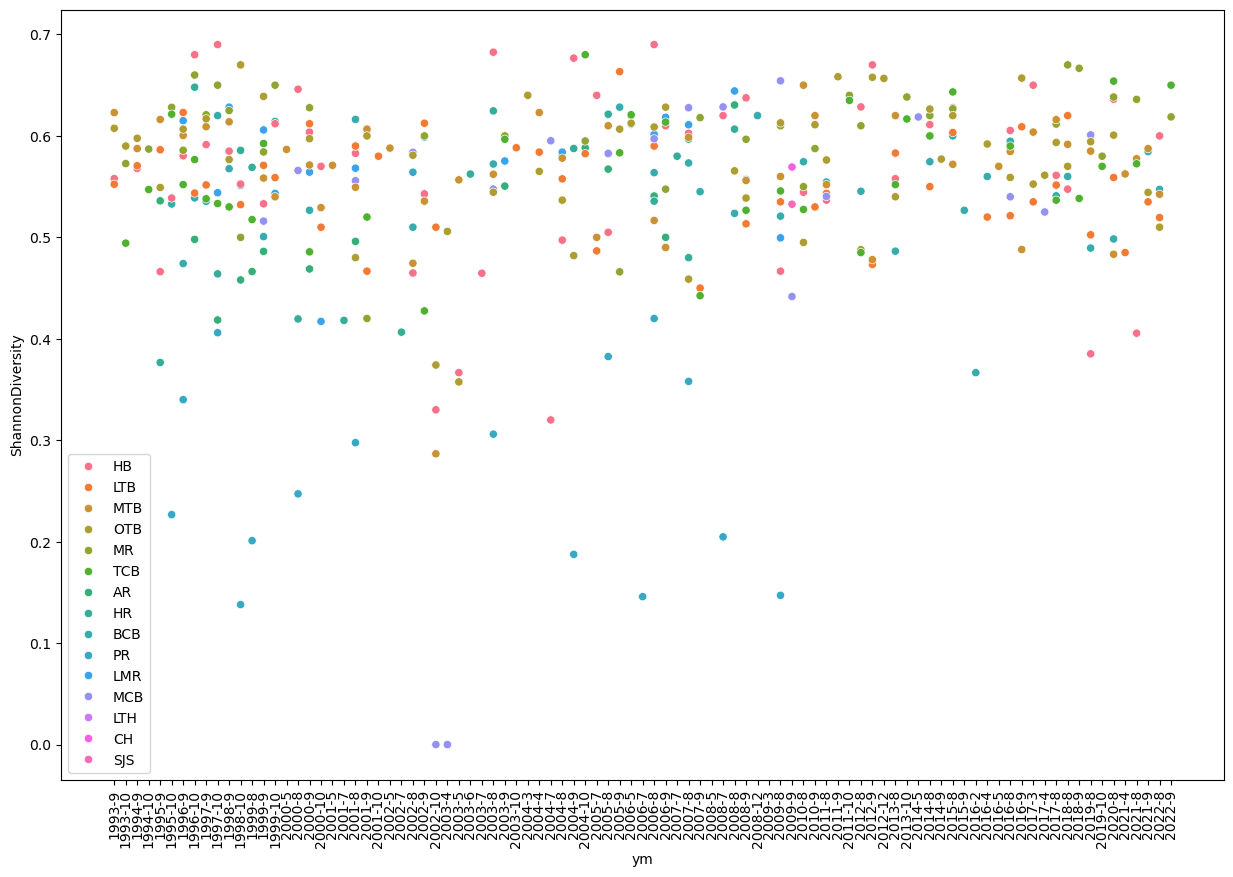

In [52]:
plt.figure(figsize=(15,10))
sns.scatterplot(x='ym',y='ShannonDiversity',data=benX_sindex,hue='AreaAbbr')
plt.legend()
plt.xticks(rotation=90)
plt.show()

In [53]:
"""
There's going to be an issue with missing months in sampling of benthic data. There is no consistency and looking how erratic the data is already
imputation might not be the best idea.

I'm going to put this on hold and calculate the Shannon Diversity Index for the Nekton species
"""

"\nThere's going to be an issue with missing months in sampling of benthic data. There is no consistency and looking how erratic the data is already\nimputation might not be the best idea.\n\nI'm going to put this on hold and calculate the Shannon Diversity Index for the Nekton species\n"

### Nekton

##### Nekton Shannon Diversity Index (frequency, richness, abundance)


In [54]:
#Reorganizing
catch_sel_vals.drop(columns='sgyear',inplace=True)
catch_sel_vals.drop(columns='areas',inplace=True)
catch_sel_vals.drop(columns='month',inplace=True)
catch_sel_vals=pd.concat([catch_sel_vals,catch_sel.sgyear],axis=1)
catch_sel_vals=pd.concat([catch_sel_vals,catch_sel.areas],axis=1)
catch_sel_vals=pd.concat([catch_sel_vals,catch_sel.month],axis=1)

In [55]:
catch_sel_vals

,Aca_quadricornis,Ach_lineatus,Achiridae_spp,Adi_xenica,Aet_narinari,Albula_spp,Alu_schoepfii,Ana_criniger,Anc_cubana,Anc_hepsetus,Anc_lyolepis,Anc_mitchilli,Anchoa_spp,Arc_probatocephalus,Argopecten_spp,Ari_felis,Ast_y_graecum,Bag_marinus,Bai_chrysoura,Bat_soporator,Bathygobius_spp,Brevoortia_spp,Cal_arctifrons,Cal_ornatus,Cal_penna,Cal_sapidus,Cal_similis,Calamus_spp,Callinectes_spp,Car_hippos,Car_leucas,Car_limbatus,Cen_striata,Cen_undecimalis,Cha_faber,Cha_saburrae,Chi_schoepfii,Chl_chrysurus,Cit_macrops,Clupeidae_spp,Cte_boleosoma,Cte_smaragdus,Cyn_arenarius,Cyn_nebulosus,Cyp_variegatus,Dac_moorei,Dactyloscopidae_spp,Das_americana,Das_sabina,Das_say,Dia_auratus,Diapterus_spp,Dip_formosum,Dip_holbrookii,Dor_petenense,Ech_neucratoides,Elo_saurus,Elo_smithi,Elopiformes_spp,Etr_crossotus,Euc_argenteus,Euc_gula,Euc_harengulus,Eucinostomus_spp,Eug_plumieri,Far_duorarum,Flo_carpio,Fun_confluentus,Fun_grandis,Fun_similis,Gob_bosc,Gob_longipala,Gob_robustum,Gob_strumosus,Gobiosoma_spp,Gym_micrura,Hae_aurolineatum,Hae_plumierii,Har_jaguana,Hem_balao,Hemiramphidae_spp,Hemiramphus_spp,Hip_erectus,Hip_zosterae,Hippocampus_spp,Hyp_hentz,Hyp_meeki,Hyp_unifasciatus,Hyporhamphus_spp,Lactophrys_spp,Lag_rhomboides,Lei_xanthurus,Lep_osseus,Lim_polyphemus,Lop_cyprinoides,Luc_parva,Lut_analis,Lut_griseus,Lut_synagris,Mem_martinica,Men_americanus,Men_saxatilis,Menidia_spp,Menippe_spp,Menticirrhus_spp,Mic_gulosus,Mic_thalassinus,Mic_undulatus,Mon_ciliatus,Mug_cephalus,Mug_curema,Mug_trichodon,Mugil_spp,Myc_microlepis,Myr_punctatus,Nic_usta,Ogc_cubifrons,Oli_saurus,Opi_oglinum,Ops_beta,Ore_aureus,Oreo_Saroth_spp,Ort_chrysoptera,Ostraciidae_spp,Par_albigutta,Par_marmoratus,Penaeidae_spp,Pep_paru,Poe_latipinna,Pog_cromis,Pom_saltatrix,Portunus_spp,Pri_scitulus,Pri_tribulus,Rhi_bonasus,Rim_constrictus,Rimapenaeus_spp,Sar_aurita,Sar_melanotheron,Sci_ocellatus,Sciaenidae_spp,Sco_brasiliensis,Sco_maculatus,Sel_vomer,Sph_barracuda,Sph_borealis,Sph_nephelus,Sph_spengleri,Sph_tiburo,Sphoeroides_spp,Ste_hispidus,Ste_setifer,Str_marina,Str_notata,Str_timucu,Strongylura_spp,Sym_plagiusa,Syn_floridae,Syn_foetens,Syn_louisianae,Syn_scovelli,Syngnathidae_spp,Synodontidae_spp,Tra_carolinus,Tra_falcatus,Tri_maculatus,Tyl_crocodilus,Uro_floridana,v_algae,v_algae:_filamentous_green,v_algae:_filamentous_red,v_caulerpa_spp.,v_gracillaria,v_halodule_spp.,v_halophila_spp.,v_ruppia_spp.,v_sav,v_savalg,v_sargassum_spp,v_seagrasses:_mixed,v_seagrasses:_unidentified,v_syringodium_spp.,v_thalassia_spp.,Fall,Spring,Summer,Winter,HB,LTB,MTB,OTB,sgyear,areas,month
0,0,0,0,0,0,0,0,0,0,0,0,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1999,22,01
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1999,21,01
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1999,21,01
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

##### Catch Frequency 

In [56]:
#Checking for last
catch_sel.columns[176]

'season_conv'

In [57]:
# Drop non-animal species or columns
catch_freq_stage=catch_sel.drop(columns=catch_sel.columns[170:177])
catch_freq_stage

,month,Reference,Aca_quadricornis,Ach_lineatus,Achiridae_spp,Adi_xenica,Aet_narinari,Albula_spp,Alu_schoepfii,Ana_criniger,Anc_cubana,Anc_hepsetus,Anc_lyolepis,Anc_mitchilli,Anchoa_spp,Arc_probatocephalus,Argopecten_spp,Ari_felis,Ast_y_graecum,Bag_marinus,Bai_chrysoura,Bat_soporator,Bathygobius_spp,Brevoortia_spp,Cal_arctifrons,Cal_ornatus,Cal_penna,Cal_sapidus,Cal_similis,Calamus_spp,Callinectes_spp,Car_hippos,Car_leucas,Car_limbatus,Cen_striata,Cen_undecimalis,Cha_faber,Cha_saburrae,Chi_schoepfii,Chl_chrysurus,Cit_macrops,Clupeidae_spp,Cte_boleosoma,Cte_smaragdus,Cyn_arenarius,Cyn_nebulosus,Cyp_variegatus,Dac_moorei,Dactyloscopidae_spp,Das_americana,Das_sabina,Das_say,Dia_auratus,Diapterus_spp,Dip_formosum,Dip_holbrookii,Dor_petenense,Ech_neucratoides,Elo_saurus,Elo_smithi,Elopiformes_spp,Etr_crossotus,Euc_argenteus,Euc_gula,Euc_harengulus,Eucinostomus_spp,Eug_plumieri,Far_duorarum,Flo_carpio,Fun_confluentus,Fun_grandis,Fun_similis,Gob_bosc,Gob_longipala,Gob_robustum,Gob_strumosus,Gobiosoma_spp,Gym_micrura,Hae_aurolineatum,Hae_plumierii,Har_jaguana,Hem_balao,Hemiramphidae_spp,Hemiramphus_spp,Hip_erectus,Hip_zosterae,Hippocampus_spp,Hyp_hentz,Hyp_meeki,Hyp_unifasciatus,Hyporhamphus_spp,Lactophrys_spp,Lag_rhomboides,Lei_xanthurus,Lep_osseus,Lim_polyphemus,Lop_cyprinoides,Luc_parva,Lut_analis,Lut_griseus,Lut_synagris,Mem_martinica,Men_americanus,Men_saxatilis,Menidia_spp,Menippe_spp,Menticirrhus_spp,Mic_gulosus,Mic_thalassinus,Mic_undulatus,Mon_ciliatus,Mug_cephalus,Mug_curema,Mug_trichodon,Mugil_spp,Myc_microlepis,Myr_punctatus,Nic_usta,Ogc_cubifrons,Oli_saurus,Opi_oglinum,Ops_beta,Ore_aureus,Oreo_Saroth_spp,Ort_chrysoptera,Ostraciidae_spp,Par_albigutta,Par_marmoratus,Penaeidae_spp,Pep_paru,Poe_latipinna,Pog_cromis,Pom_saltatrix,Portunus_spp,Pri_scitulus,Pri_tribulus,Rhi_bonasus,Rim_constrictus,Rimapenaeus_spp,Sar_aurita,Sar_melanotheron,Sci_ocellatus,Sciaenidae_spp,Sco_brasiliensis,Sco_maculatus,Sel_vomer,Sph_barracuda,Sph_borealis,Sph_nephelus,Sph_spengleri,Sph_tiburo,Sphoeroides_spp,Ste_hispidus,Ste_setifer,Str_marina,Str_notata,Str_timucu,Strongylura_spp,Sym_plagiusa,Syn_floridae,Syn_foetens,Syn_louisianae,Syn_scovelli,Syngnathidae_spp,Synodontidae_spp,Tra_carolinus,Tra_falcatus,Tri_maculatus,Tyl_crocodilus,Uro_floridana
0,01,TBM1998010906,0,0,0,0,0,0,0,0,0,0,0,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,01,TBM1998010910,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,01,TBM1998010912,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,01,TBM1998010914,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,01,TBM1998010915,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,5,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

These are not dummy variables - they are species by column and number of organism catch in any given sampling event. There are a number of columns that could be combined but that won't have any significant effect.

In [58]:
#drop first 2 columns
catch_freq_stage.drop(columns=['month','Reference'],inplace=True)

In [59]:
catch_freq_stage

,Aca_quadricornis,Ach_lineatus,Achiridae_spp,Adi_xenica,Aet_narinari,Albula_spp,Alu_schoepfii,Ana_criniger,Anc_cubana,Anc_hepsetus,Anc_lyolepis,Anc_mitchilli,Anchoa_spp,Arc_probatocephalus,Argopecten_spp,Ari_felis,Ast_y_graecum,Bag_marinus,Bai_chrysoura,Bat_soporator,Bathygobius_spp,Brevoortia_spp,Cal_arctifrons,Cal_ornatus,Cal_penna,Cal_sapidus,Cal_similis,Calamus_spp,Callinectes_spp,Car_hippos,Car_leucas,Car_limbatus,Cen_striata,Cen_undecimalis,Cha_faber,Cha_saburrae,Chi_schoepfii,Chl_chrysurus,Cit_macrops,Clupeidae_spp,Cte_boleosoma,Cte_smaragdus,Cyn_arenarius,Cyn_nebulosus,Cyp_variegatus,Dac_moorei,Dactyloscopidae_spp,Das_americana,Das_sabina,Das_say,Dia_auratus,Diapterus_spp,Dip_formosum,Dip_holbrookii,Dor_petenense,Ech_neucratoides,Elo_saurus,Elo_smithi,Elopiformes_spp,Etr_crossotus,Euc_argenteus,Euc_gula,Euc_harengulus,Eucinostomus_spp,Eug_plumieri,Far_duorarum,Flo_carpio,Fun_confluentus,Fun_grandis,Fun_similis,Gob_bosc,Gob_longipala,Gob_robustum,Gob_strumosus,Gobiosoma_spp,Gym_micrura,Hae_aurolineatum,Hae_plumierii,Har_jaguana,Hem_balao,Hemiramphidae_spp,Hemiramphus_spp,Hip_erectus,Hip_zosterae,Hippocampus_spp,Hyp_hentz,Hyp_meeki,Hyp_unifasciatus,Hyporhamphus_spp,Lactophrys_spp,Lag_rhomboides,Lei_xanthurus,Lep_osseus,Lim_polyphemus,Lop_cyprinoides,Luc_parva,Lut_analis,Lut_griseus,Lut_synagris,Mem_martinica,Men_americanus,Men_saxatilis,Menidia_spp,Menippe_spp,Menticirrhus_spp,Mic_gulosus,Mic_thalassinus,Mic_undulatus,Mon_ciliatus,Mug_cephalus,Mug_curema,Mug_trichodon,Mugil_spp,Myc_microlepis,Myr_punctatus,Nic_usta,Ogc_cubifrons,Oli_saurus,Opi_oglinum,Ops_beta,Ore_aureus,Oreo_Saroth_spp,Ort_chrysoptera,Ostraciidae_spp,Par_albigutta,Par_marmoratus,Penaeidae_spp,Pep_paru,Poe_latipinna,Pog_cromis,Pom_saltatrix,Portunus_spp,Pri_scitulus,Pri_tribulus,Rhi_bonasus,Rim_constrictus,Rimapenaeus_spp,Sar_aurita,Sar_melanotheron,Sci_ocellatus,Sciaenidae_spp,Sco_brasiliensis,Sco_maculatus,Sel_vomer,Sph_barracuda,Sph_borealis,Sph_nephelus,Sph_spengleri,Sph_tiburo,Sphoeroides_spp,Ste_hispidus,Ste_setifer,Str_marina,Str_notata,Str_timucu,Strongylura_spp,Sym_plagiusa,Syn_floridae,Syn_foetens,Syn_louisianae,Syn_scovelli,Syngnathidae_spp,Synodontidae_spp,Tra_carolinus,Tra_falcatus,Tri_maculatus,Tyl_crocodilus,Uro_floridana
0,0,0,0,0,0,0,0,0,0,0,0,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,5,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,..

In [60]:
# Get proportions of nekton species, sum across row = 1
# Deal with NaN values. Will encounter div/0 errors
freq=catch_freq_stage.div(catch_freq_stage.sum(axis=1), axis=0)
freq=freq.fillna(0)
freq

,Aca_quadricornis,Ach_lineatus,Achiridae_spp,Adi_xenica,Aet_narinari,Albula_spp,Alu_schoepfii,Ana_criniger,Anc_cubana,Anc_hepsetus,Anc_lyolepis,Anc_mitchilli,Anchoa_spp,Arc_probatocephalus,Argopecten_spp,Ari_felis,Ast_y_graecum,Bag_marinus,Bai_chrysoura,Bat_soporator,Bathygobius_spp,Brevoortia_spp,Cal_arctifrons,Cal_ornatus,Cal_penna,Cal_sapidus,Cal_similis,Calamus_spp,Callinectes_spp,Car_hippos,Car_leucas,Car_limbatus,Cen_striata,Cen_undecimalis,Cha_faber,Cha_saburrae,Chi_schoepfii,Chl_chrysurus,Cit_macrops,Clupeidae_spp,Cte_boleosoma,Cte_smaragdus,Cyn_arenarius,Cyn_nebulosus,Cyp_variegatus,Dac_moorei,Dactyloscopidae_spp,Das_americana,Das_sabina,Das_say,Dia_auratus,Diapterus_spp,Dip_formosum,Dip_holbrookii,Dor_petenense,Ech_neucratoides,Elo_saurus,Elo_smithi,Elopiformes_spp,Etr_crossotus,Euc_argenteus,Euc_gula,Euc_harengulus,Eucinostomus_spp,Eug_plumieri,Far_duorarum,Flo_carpio,Fun_confluentus,Fun_grandis,Fun_similis,Gob_bosc,Gob_longipala,Gob_robustum,Gob_strumosus,Gobiosoma_spp,Gym_micrura,Hae_aurolineatum,Hae_plumierii,Har_jaguana,Hem_balao,Hemiramphidae_spp,Hemiramphus_spp,Hip_erectus,Hip_zosterae,Hippocampus_spp,Hyp_hentz,Hyp_meeki,Hyp_unifasciatus,Hyporhamphus_spp,Lactophrys_spp,Lag_rhomboides,Lei_xanthurus,Lep_osseus,Lim_polyphemus,Lop_cyprinoides,Luc_parva,Lut_analis,Lut_griseus,Lut_synagris,Mem_martinica,Men_americanus,Men_saxatilis,Menidia_spp,Menippe_spp,Menticirrhus_spp,Mic_gulosus,Mic_thalassinus,Mic_undulatus,Mon_ciliatus,Mug_cephalus,Mug_curema,Mug_trichodon,Mugil_spp,Myc_microlepis,Myr_punctatus,Nic_usta,Ogc_cubifrons,Oli_saurus,Opi_oglinum,Ops_beta,Ore_aureus,Oreo_Saroth_spp,Ort_chrysoptera,Ostraciidae_spp,Par_albigutta,Par_marmoratus,Penaeidae_spp,Pep_paru,Poe_latipinna,Pog_cromis,Pom_saltatrix,Portunus_spp,Pri_scitulus,Pri_tribulus,Rhi_bonasus,Rim_constrictus,Rimapenaeus_spp,Sar_aurita,Sar_melanotheron,Sci_ocellatus,Sciaenidae_spp,Sco_brasiliensis,Sco_maculatus,Sel_vomer,Sph_barracuda,Sph_borealis,Sph_nephelus,Sph_spengleri,Sph_tiburo,Sphoeroides_spp,Ste_hispidus,Ste_setifer,Str_marina,Str_notata,Str_timucu,Strongylura_spp,Sym_plagiusa,Syn_floridae,Syn_foetens,Syn_louisianae,Syn_scovelli,Syngnathidae_spp,Synodontidae_spp,Tra_carolinus,Tra_falcatus,Tri_maculatus,Tyl_crocodilus,Uro_floridana
0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.882353,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.117647,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.

**Get proportion freq for all nekton species**


In [62]:
freq.loc[1].isna()==True

Aca_quadricornis    False
Ach_lineatus        False
Achiridae_spp       False
Adi_xenica          False
Aet_narinari        False
                    ...  
Tra_carolinus       False
Tra_falcatus        False
Tri_maculatus       False
Tyl_crocodilus      False
Uro_floridana       False
Name: 1, Length: 168, dtype: bool

In [63]:
shannon= -(freq * np.log(freq)).sum(axis=1)

C:\Users\Ajax\miniconda3\envs\bs\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


In [64]:
shannon

0       0.362211
1      -0.000000
2      -0.000000
3       0.693147
4       1.162226
          ...   
4570    0.688567
4571    1.589084
4572    1.332179
4573    2.264088
4574    1.054920
Length: 4575, dtype: float64

#### VIF check: Checking for MultiColinearity

In [65]:
catch_sel_vals.iloc[:,170]

0       0
1       0
2       0
3       0
4       0
       ..
4570    0
4571    0
4572    0
4573    0
4574    0
Name: v_algae:_filamentous_red, Length: 4575, dtype: int32

In [66]:
non_num=[]
for i in catch_sel_vals.columns:
    if catch_sel_vals[i].dtype == 'object':
        non_num.append(i)

In [67]:
non_num

['month']

In [68]:
catch_sel_vals['month']=catch_sel_vals.month.astype('int')

In [69]:
catch_sel_vals.columns[168]

'v_algae'

In [70]:
VIFcheck=catch_sel_vals.drop(columns=catch_sel_vals.columns[168:194])

In [71]:
VIFcheck_withconstant=sm.add_constant(VIFcheck)

In [ ]:
for i in VIFcheck_withconstant.columns:
    print(VIFcheck_withconstant[i].dtype)
    print(VIFcheck_withconstant[i].dtype not in ('float64','int64'))

In [73]:
VIF_coef=pd.Series([variance_inflation_factor(VIFcheck_withconstant.values, i)
          for i in range(VIFcheck_withconstant.shape[1])],
         index=VIFcheck_withconstant.columns)[1:] # leaving out the constant

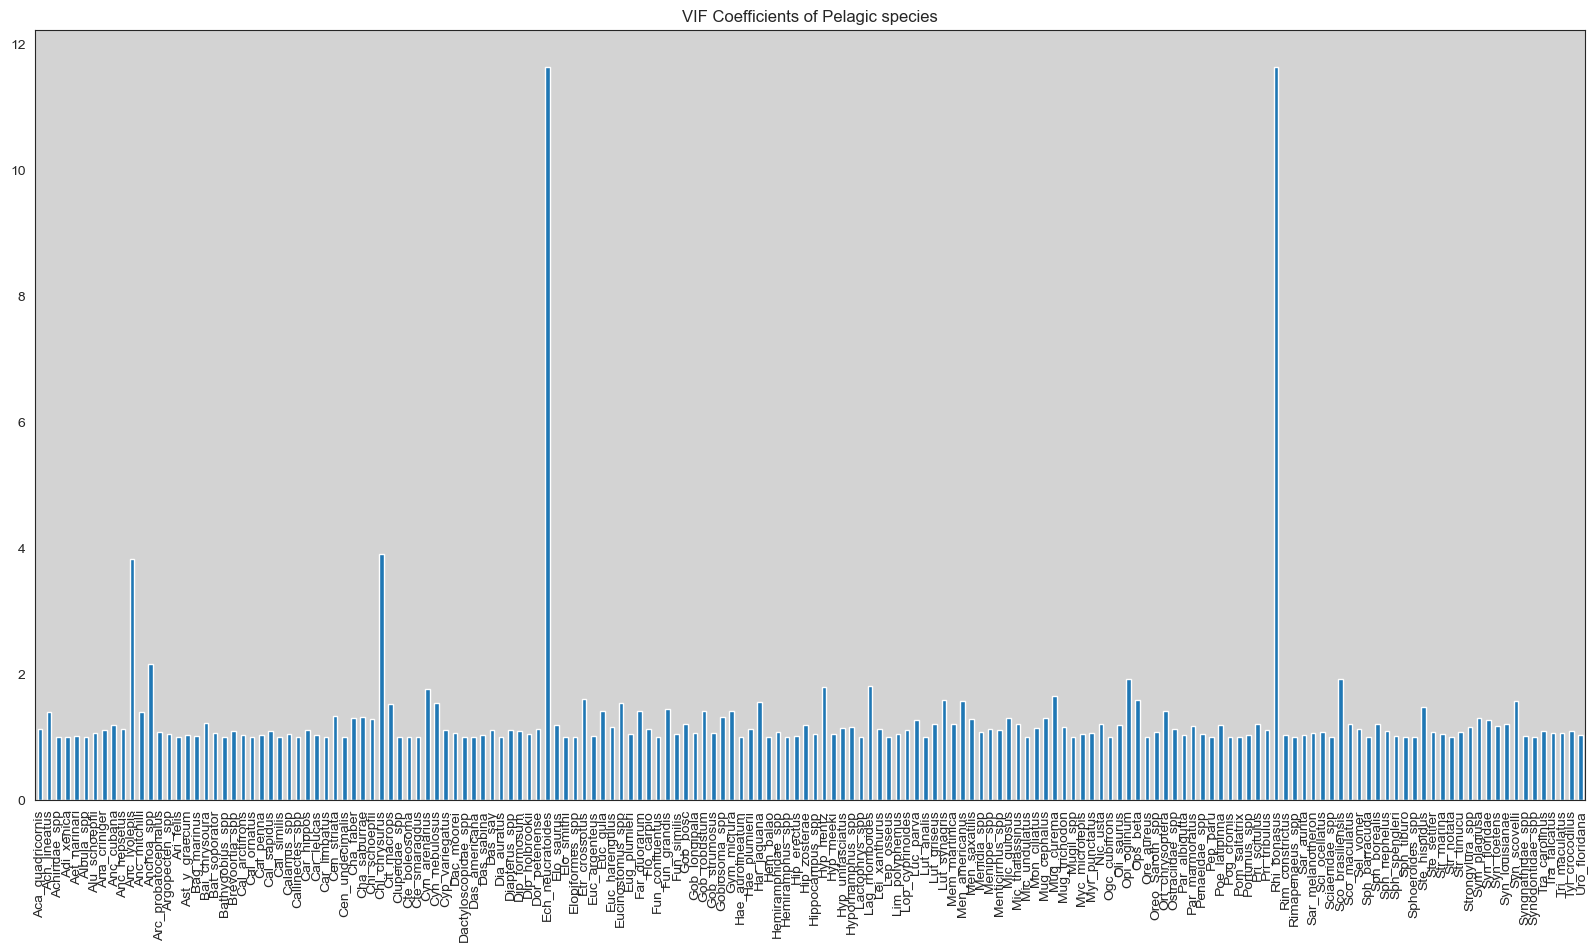

In [601]:
plt.figure(figsize=(20,10))
VIF_coef.plot(kind='bar')
plt.title('VIF Coefficients of Pelagic species')
plt.show()

In [75]:
VIF_coef[VIF_coef>3]

Anc_lyolepis         3.836255
Chl_chrysurus        3.909879
Ech_neucratoides    11.639851
Rhi_bonasus         11.646314
dtype: float64

In [76]:
multico_col=VIF_coef[VIF_coef>3]

In [77]:
multico_col.info()

<class 'pandas.core.series.Series'>
Index: 4 entries, Anc_lyolepis to Rhi_bonasus
Series name: None
Non-Null Count  Dtype  
--------------  -----  
4 non-null      float64
dtypes: float64(1)
memory usage: 64.0+ bytes


#### Lasso and Ridge Regression

In [78]:
multico_col

Anc_lyolepis         3.836255
Chl_chrysurus        3.909879
Ech_neucratoides    11.639851
Rhi_bonasus         11.646314
dtype: float64

In [79]:
shannon

0       0.362211
1      -0.000000
2      -0.000000
3       0.693147
4       1.162226
          ...   
4570    0.688567
4571    1.589084
4572    1.332179
4573    2.264088
4574    1.054920
Length: 4575, dtype: float64

In [80]:
multico_col=multico_col.reset_index(name='VIF_coef')

In [81]:
multico_col.rename(columns={'index': 'species'},inplace=True )

In [82]:
freq[multico_col.species].sum()

Anc_lyolepis        0.001590
Chl_chrysurus       3.105227
Ech_neucratoides    0.021739
Rhi_bonasus         4.646536
dtype: float64

In [83]:
shannon=pd.Series(shannon)

In [84]:
catch_sel_vals=pd.concat([catch_sel_vals,shannon],axis=1).rename(columns={0:'shannon'})

In [85]:
catch_sel_vals.OTB=catch_sel_vals.OTB.astype(int)

In [379]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(catch_sel_vals.drop(columns='shannon'), catch_sel_vals.shannon, test_size=0.2, random_state=42)

In [372]:
myLasso_nekton=Lasso()
myRidge_nekton=Ridge()

In [381]:
myLasso_nekton.fit(X_train,y_train)
myRidge_nekton.fit(X_train,y_train)

Ridge()

In [382]:
myLasso_nekton.score(X_test,y_test)

-7.798142002424235e-05

In [383]:
myRidge_nekton.score(X_test,y_test)

-2.873901988658714

In [384]:
myLasso_nekton.coef_

array([ 0.,  0.,  0.,  0.,  0., -0.,  0.,  0.,  0.,  0.,  0., -0.,  0.,
        0., -0.,  0., -0.,  0.,  0., -0.,  0.,  0.,  0., -0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
       -0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0., -0.,  0., -0.,  0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
       -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.,
       -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.,  0.,  0., -0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0., -0., -0.,  0.,  0.,  0.,  0., -0.,
        0.,  0.,  0.,  0., -0., -0.,  0.,  0.,  0.,  0., -0.,  0.,  0.,
        0.,  0.,  0.,  0., -0.,  0.,  0., -0.,  0.,  0., -0.,  0., -0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.,  0.,  0., -0., -0.,
       -0., -0.,  0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0

In [ ]:
myRidge_nekton

#### PCA Analysis

In [380]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [88]:
from sklearn.decomposition import PCA

# Create the PCA - we will retain the same number of components as our input variables
my_pca = PCA(n_components=100)
my_pca.fit(X_train)
X_PCA=my_pca.transform(X_train)

In [89]:
my_pca3D = PCA(n_components=3)
my_pca3D.fit(X_train)
X_PCA3D=my_pca3D.transform(X_train)

In [90]:
X_PCA

array([[-0.30893289, -0.47661834,  0.34964873, ...,  0.00311358,
         0.0286419 ,  0.10319131],
       [-0.8418328 , -0.5599577 ,  0.89674082, ...,  0.04573803,
        -0.04384761,  0.10714894],
       [ 0.17641027, -0.65245307,  0.36428149, ..., -0.1397307 ,
        -0.18442215,  0.12691149],
       ...,
       [-1.40109569,  0.41963312,  2.48317399, ...,  0.27101523,
         0.15688373, -0.02924368],
       [ 0.11660483,  2.38329859, -0.31298804, ...,  0.29887122,
        -0.34172371,  0.43288061],
       [ 0.56148699, -1.10356711,  0.19491423, ..., -2.91950707,
        -1.65765755,  0.05876643]])

In [91]:
X_PCA3D

array([[-0.30893289, -0.47661834,  0.34964873],
       [-0.8418328 , -0.5599577 ,  0.89674082],
       [ 0.17641027, -0.65245307,  0.36428149],
       ...,
       [-1.40109569,  0.41963312,  2.48317399],
       [ 0.11660483,  2.38329859, -0.31298804],
       [ 0.56148699, -1.10356711,  0.19491423]])

In [92]:
my_pca.explained_variance_ratio_[0]

0.020938652756011773

In [ ]:
cum_sum=0
n_components=1
for i in range(0,100):
    cum_sum=cum_sum+my_pca.explained_variance_ratio_[i]
    print(f'Number of Components: {n_components}')
    print(round(cum_sum,5))
    n_components+=1    

__Doing the rest of the PCA seems like it won't provide much information. 20 components only explains 21.7%.<br>
When 100 components were calculated, it still didn't reach 70% <br>
However, a 3D plot of the first 3 PC does look a lot more relevant than non-scaled data.__

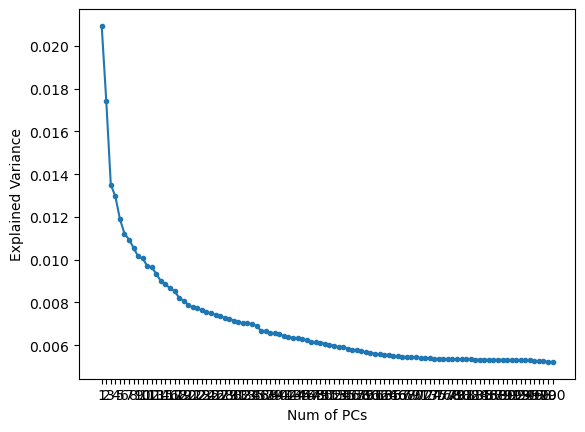

In [94]:
plt.figure()
plt.plot(np.arange(100)+1, my_pca.explained_variance_ratio_, marker = '.')
plt.xticks(np.arange(100)+1)
plt.ylabel('Explained Variance')
plt.xlabel('Num of PCs')
plt.show()

In [95]:
PCA3D = pd.DataFrame(data=X_PCA3D, columns=['PC1', 'PC2', 'PC3'])

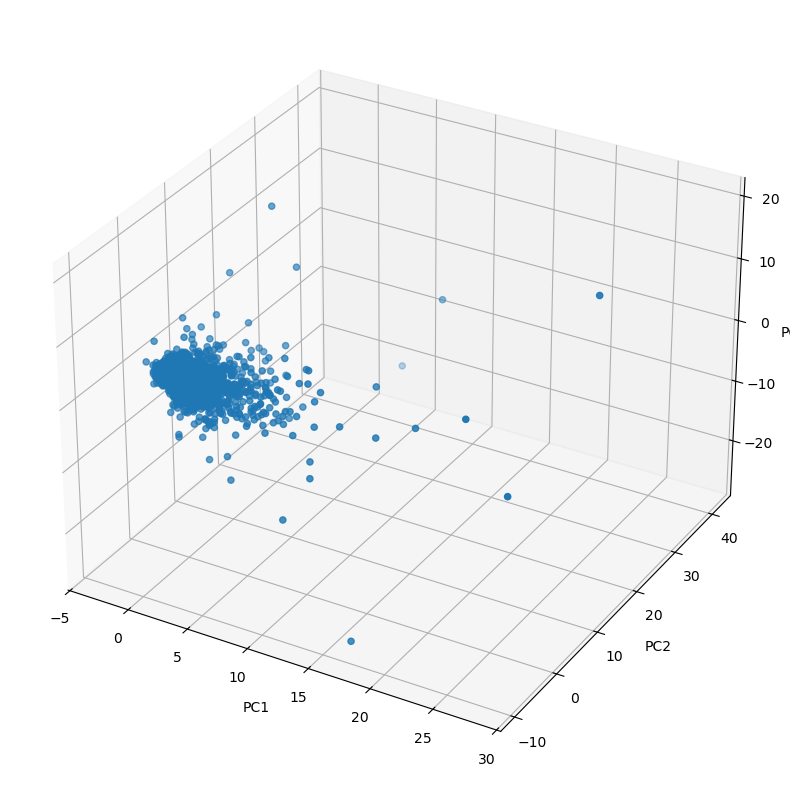

In [96]:
fig = plt.figure(figsize=(10,10,))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(PCA3D['PC1'], PCA3D['PC2'], PCA3D['PC3'])
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()

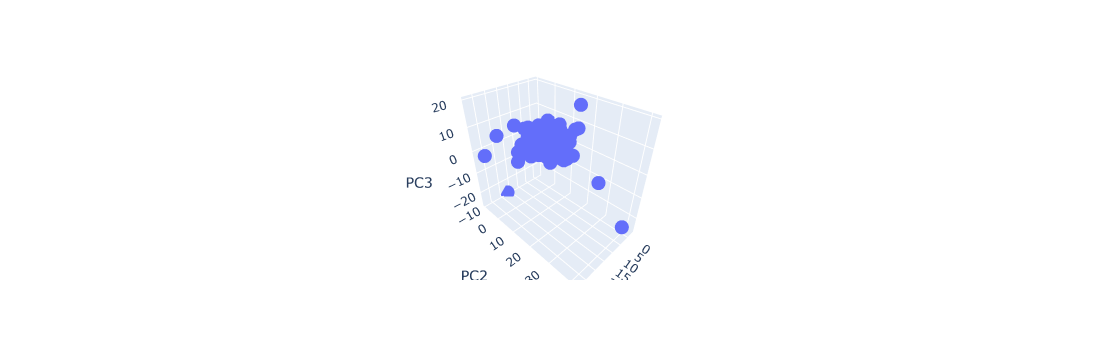

<Figure size 1000x1000 with 0 Axes>

In [97]:
import plotly.express as px
fig=plt.figure(figsize=(10,10))
fig = px.scatter_3d(PCA3D, x='PC1', y='PC2', z='PC3')
fig.show()

In [98]:
my_pca3D = PCA(n_components=3)
my_pca3D.fit(X_train)
X_PCA3D=my_pca3D.transform(X_train)

In [99]:
X_PCA

array([[-0.30893289, -0.47661834,  0.34964873, ...,  0.00311358,
         0.0286419 ,  0.10319131],
       [-0.8418328 , -0.5599577 ,  0.89674082, ...,  0.04573803,
        -0.04384761,  0.10714894],
       [ 0.17641027, -0.65245307,  0.36428149, ..., -0.1397307 ,
        -0.18442215,  0.12691149],
       ...,
       [-1.40109569,  0.41963312,  2.48317399, ...,  0.27101523,
         0.15688373, -0.02924368],
       [ 0.11660483,  2.38329859, -0.31298804, ...,  0.29887122,
        -0.34172371,  0.43288061],
       [ 0.56148699, -1.10356711,  0.19491423, ..., -2.91950707,
        -1.65765755,  0.05876643]])

In [100]:
"""
Before scaling, it looked like onlt 100 components explained 70% of the data.
"""

'\nBefore scaling, it looked like onlt 100 components explained 70% of the data.\n'

In [101]:
my_pca5 = PCA(n_components=5)
my_pca5.fit(X_train)
X_PCA5=my_pca5.transform(catch_sel_vals.drop(columns='shannon'))

C:\Users\Ajax\miniconda3\envs\bs\Lib\site-packages\sklearn\base.py:486: UserWarning:

X has feature names, but PCA was fitted without feature names



In [102]:
X_PCA5

array([[  -8.84132463,  -72.04857644,   24.41794395,   15.22130717,
        -105.24072356],
       [ -11.69969393,  -72.01970132,   23.44692998,   11.82410624,
        -105.32094301],
       [ -11.95796118,  -71.9885351 ,   23.46822794,   11.85790268,
        -105.28396478],
       ...,
       [ -10.58564569,  -71.45117253,   18.9158919 ,   13.21633614,
        -107.18561537],
       [  -1.57158295,  -71.74449648,   23.01137899,    9.69493869,
        -107.61706131],
       [ -10.04163576,  -72.10984277,   19.30175926,   13.00086305,
        -107.397504  ]])

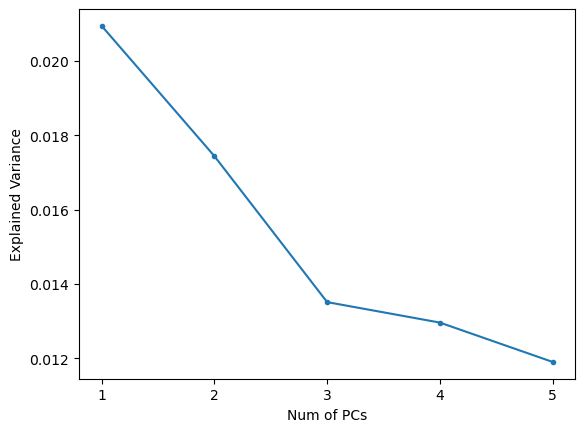

In [103]:
plt.figure()
plt.plot(np.arange(5)+1, my_pca5.explained_variance_ratio_, marker = '.')
plt.xticks(np.arange(5)+1)
plt.ylabel('Explained Variance')
plt.xlabel('Num of PCs')
plt.show()

In [104]:
X_PCA5_df=pd.DataFrame(X_PCA5, columns=['PCA-1', 'PCA-2','PCA-3','PCA-4','PCA-5'])

In [105]:
X_PCA5_df['shannon']=catch_sel_vals['shannon']

In [106]:
X_PCA5_df['shannon']=catch_sel_vals['shannon']

In [107]:
X_PCA5_df.isna().sum()

PCA-1      0
PCA-2      0
PCA-3      0
PCA-4      0
PCA-5      0
shannon    0
dtype: int64

In [108]:
PCA_DF=pd.DataFrame(X_PCA)

In [109]:
E = H / ln(k)

NameError: name 'H' is not defined

In [ ]:
PCA_DF

In [110]:
my_pca.explained_variance_ratio_

array([0.02093865, 0.01743772, 0.01351384, 0.01296366, 0.01190606,
       0.01122407, 0.01094361, 0.01055977, 0.01015256, 0.0100578 ,
       0.00970787, 0.00964545, 0.00933558, 0.00899738, 0.00884683,
       0.00867228, 0.00853647, 0.00821578, 0.00808214, 0.00788865,
       0.0077692 , 0.00774816, 0.00762503, 0.00754837, 0.00750593,
       0.00742204, 0.00735219, 0.0072861 , 0.00724879, 0.00715303,
       0.00707325, 0.00703842, 0.00702898, 0.00697908, 0.00691017,
       0.00667312, 0.00665155, 0.00656241, 0.00655305, 0.00650364,
       0.00643847, 0.00639537, 0.00635067, 0.00631802, 0.00628814,
       0.0062402 , 0.00615903, 0.00613374, 0.00612131, 0.00606627,
       0.00603118, 0.00598058, 0.00591421, 0.0059112 , 0.00583802,
       0.00579595, 0.00576945, 0.00573959, 0.005661  , 0.00563824,
       0.00561095, 0.00557392, 0.00556439, 0.00555316, 0.00551145,
       0.00547441, 0.00546365, 0.00545409, 0.00543318, 0.00542712,
       0.00540927, 0.00538715, 0.00538193, 0.00537283, 0.00536

In [111]:
X_train_PCA=my_pca.transform(X_train)

In [112]:
X_test_PCA=my_pca.transform(X_test)

In [113]:
from sklearn.linear_model import LinearRegression
LinReg=LinearRegression()
LinReg.fit(X_train_PCA,y_train)

LinearRegression()

In [114]:
y_pred_train=LinReg.predict(X_train_PCA)

In [115]:
y_pred_train=LinReg.predict(X_test_PCA)

In [116]:
LinReg.score(X_train_PCA,y_train)

0.25350355413809744

In [117]:
#Results
# n_components =20, score= 0.195
# n_components = 100, score=0.2535

Nitrates and Phosphates

In [118]:
os.chdir('J:\\Brainstation\\Capstone Git\\data\\human Imact')

In [119]:
NP_Means=pd.read_csv('nitrate_phosphate_totals_1990_2024.csv')

In [120]:
NP_Means

,Unnamed: 0,year,month,ym,ResultValue2,ActivityDepth,Latitude,Longitude,pyear,pmonth,pResultUnit,Phos,p_ym
0,0,1990,1,1990_1,0.682750,2.319250,27.795134,-82.504102,1990,1,mg/l,0.525385,1990_1
1,1,1990,2,1990_2,0.847750,2.451250,27.792931,-82.504449,1990,2,mg/l,0.534000,1990_2
2,2,1990,3,1990_3,0.641500,2.362000,27.792931,-82.504449,1990,3,mg/l,0.469091,1990_3
3,3,1990,4,1990_4,0.630976,2.224878,27.794969,-82.502239,1990,4,mg/l,0.529375,1990_4
4,4,1990,5,1990_5,0.676829,2.543902,27.794969,-82.502239,1990,5,mg/l,0.649000,1990_5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,411,2024,4,2024_4,0.442958,2.052083,27.795194,-82.496064,2024,4,mg/l,0.129429,2024_4
412,412,2024,5,2024_5,0.330565,2.039130,27.800788,-82.493325,2024,5,mg/l,0.111750,2024_5
413,413,2024,6,2024_6,0.355957,2.219565,27.800788,-82.493325,2024,6,mg/l,0.112889,2024_6
414,414,2024,7,2024_7,0.182000,2.494118,27.778137,-82.513610,2024,7,mg/l,0.124333,2024_7


In [121]:
NP_Means.rename(columns={'ResultValue2':'Nit'},inplace=True)

In [122]:
NP_Means.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     416 non-null    int64  
 1   year           416 non-null    int64  
 2   month          416 non-null    int64  
 3   ym             416 non-null    object 
 4   Nit            416 non-null    float64
 5   ActivityDepth  416 non-null    float64
 6   Latitude       416 non-null    float64
 7   Longitude      416 non-null    float64
 8   pyear          416 non-null    int64  
 9   pmonth         416 non-null    int64  
 10  pResultUnit    416 non-null    object 
 11  Phos           416 non-null    float64
 12  p_ym           416 non-null    object 
dtypes: float64(5), int64(5), object(3)
memory usage: 42.4+ KB


In [123]:
NP_means=NP_Means.iloc[:,[1,2,3,4,11,5,6,7]]

In [124]:
NP_means

,year,month,ym,Nit,Phos,ActivityDepth,Latitude,Longitude
0,1990,1,1990_1,0.682750,0.525385,2.319250,27.795134,-82.504102
1,1990,2,1990_2,0.847750,0.534000,2.451250,27.792931,-82.504449
2,1990,3,1990_3,0.641500,0.469091,2.362000,27.792931,-82.504449
3,1990,4,1990_4,0.630976,0.529375,2.224878,27.794969,-82.502239
4,1990,5,1990_5,0.676829,0.649000,2.543902,27.794969,-82.502239
...,...,...,...,...,...,...,...,...
411,2024,4,2024_4,0.442958,0.129429,2.052083,27.795194,-82.496064
412,2024,5,2024_5,0.330565,0.111750,2.039130,27.800788,-82.493325
413,2024,6,2024_6,0.355957,0.112889,2.219565,27.800788,-82.493325
414,2024,7,2024_7,0.182000,0.124333,2.494118,27.778137,-82.513610


### Nitrates, Phosphates, Nekton, Benthic

In [125]:
"""
Key Tables:
NP_means
"""

'\nKey Tables:\nNP_means\n'

In [126]:
catch_sel_vals

,Aca_quadricornis,Ach_lineatus,Achiridae_spp,Adi_xenica,Aet_narinari,Albula_spp,Alu_schoepfii,Ana_criniger,Anc_cubana,Anc_hepsetus,Anc_lyolepis,Anc_mitchilli,Anchoa_spp,Arc_probatocephalus,Argopecten_spp,Ari_felis,Ast_y_graecum,Bag_marinus,Bai_chrysoura,Bat_soporator,Bathygobius_spp,Brevoortia_spp,Cal_arctifrons,Cal_ornatus,Cal_penna,Cal_sapidus,Cal_similis,Calamus_spp,Callinectes_spp,Car_hippos,Car_leucas,Car_limbatus,Cen_striata,Cen_undecimalis,Cha_faber,Cha_saburrae,Chi_schoepfii,Chl_chrysurus,Cit_macrops,Clupeidae_spp,Cte_boleosoma,Cte_smaragdus,Cyn_arenarius,Cyn_nebulosus,Cyp_variegatus,Dac_moorei,Dactyloscopidae_spp,Das_americana,Das_sabina,Das_say,Dia_auratus,Diapterus_spp,Dip_formosum,Dip_holbrookii,Dor_petenense,Ech_neucratoides,Elo_saurus,Elo_smithi,Elopiformes_spp,Etr_crossotus,Euc_argenteus,Euc_gula,Euc_harengulus,Eucinostomus_spp,Eug_plumieri,Far_duorarum,Flo_carpio,Fun_confluentus,Fun_grandis,Fun_similis,Gob_bosc,Gob_longipala,Gob_robustum,Gob_strumosus,Gobiosoma_spp,Gym_micrura,Hae_aurolineatum,Hae_plumierii,Har_jaguana,Hem_balao,Hemiramphidae_spp,Hemiramphus_spp,Hip_erectus,Hip_zosterae,Hippocampus_spp,Hyp_hentz,Hyp_meeki,Hyp_unifasciatus,Hyporhamphus_spp,Lactophrys_spp,Lag_rhomboides,Lei_xanthurus,Lep_osseus,Lim_polyphemus,Lop_cyprinoides,Luc_parva,Lut_analis,Lut_griseus,Lut_synagris,Mem_martinica,Men_americanus,Men_saxatilis,Menidia_spp,Menippe_spp,Menticirrhus_spp,Mic_gulosus,Mic_thalassinus,Mic_undulatus,Mon_ciliatus,Mug_cephalus,Mug_curema,Mug_trichodon,Mugil_spp,Myc_microlepis,Myr_punctatus,Nic_usta,Ogc_cubifrons,Oli_saurus,Opi_oglinum,Ops_beta,Ore_aureus,Oreo_Saroth_spp,Ort_chrysoptera,Ostraciidae_spp,Par_albigutta,Par_marmoratus,Penaeidae_spp,Pep_paru,Poe_latipinna,Pog_cromis,Pom_saltatrix,Portunus_spp,Pri_scitulus,Pri_tribulus,Rhi_bonasus,Rim_constrictus,Rimapenaeus_spp,Sar_aurita,Sar_melanotheron,Sci_ocellatus,Sciaenidae_spp,Sco_brasiliensis,Sco_maculatus,Sel_vomer,Sph_barracuda,Sph_borealis,Sph_nephelus,Sph_spengleri,Sph_tiburo,Sphoeroides_spp,Ste_hispidus,Ste_setifer,Str_marina,Str_notata,Str_timucu,Strongylura_spp,Sym_plagiusa,Syn_floridae,Syn_foetens,Syn_louisianae,Syn_scovelli,Syngnathidae_spp,Synodontidae_spp,Tra_carolinus,Tra_falcatus,Tri_maculatus,Tyl_crocodilus,Uro_floridana,v_algae,v_algae:_filamentous_green,v_algae:_filamentous_red,v_caulerpa_spp.,v_gracillaria,v_halodule_spp.,v_halophila_spp.,v_ruppia_spp.,v_sav,v_savalg,v_sargassum_spp,v_seagrasses:_mixed,v_seagrasses:_unidentified,v_syringodium_spp.,v_thalassia_spp.,Fall,Spring,Summer,Winter,HB,LTB,MTB,OTB,sgyear,areas,month,shannon
0,0,0,0,0,0,0,0,0,0,0,0,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1999,22,1,0.362211
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1999,21,1,-0.000000
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1999,21,1,-0.000000
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [127]:
ym=catch_sel_vals.sgyear.astype(str)+'_'+catch_sel_vals.month.astype(str)

In [128]:
ym.unique()

array(['1999_1', '1999_2', '1999_3', '1999_4', '1999_5', '1999_6',
       '1999_7', '1999_8', '1999_9', '1999_10', '1999_11', '1999_12',
       '2001_1', '2001_2', '2001_3', '2001_4', '2001_5', '2001_6',
       '2001_7', '2001_8', '2001_9', '2001_10', '2001_11', '2001_12',
       '2004_1', '2004_2', '2004_3', '2004_4', '2004_5', '2004_6',
       '2004_7', '2004_8', '2004_9', '2004_10', '2004_11', '2004_12',
       '2006_1', '2006_2', '2006_3', '2006_4', '2006_5', '2006_6',
       '2006_7', '2006_8', '2006_9', '2006_10', '2006_11', '2006_12',
       '2008_1', '2008_2', '2008_3', '2008_4', '2008_5', '2008_6',
       '2008_7', '2008_8', '2008_9', '2008_10', '2008_11', '2008_12',
       '2010_1', '2010_2', '2010_3', '2010_4', '2010_5', '2010_6',
       '2010_7', '2010_8', '2010_9', '2010_10', '2010_11', '2010_12',
       '2012_1', '2012_2', '2012_3', '2012_4', '2012_5', '2012_6',
       '2012_7', '2012_8', '2012_9', '2012_10', '2012_11', '2012_12',
       '2014_1', '2014_2', '2014_3', '201

In [3]:
catch_sel_vals.sgyear.unique()

NameError: name 'catch_sel_vals' is not defined

** Sampling intervals for benthic data was not even. Data is taken both seasonally and at 2-3 year interals.
  This willmake it harder to draw direct comparisons with other datasets. **

In [130]:


vals_1999=catch_sel_vals[catch_sel_vals['sgyear']==1999]

In [132]:
SDI_means=catch_sel_vals.groupby(['month','sgyear']).shannon.mean().reset_index().sort_values(by=['sgyear','month'])

In [133]:
SDI_means

,month,sgyear,shannon
0,1,1999,0.489115
12,2,1999,0.859081
24,3,1999,0.825866
36,4,1999,0.783379
48,5,1999,0.894913
...,...,...,...
95,8,2022,0.985419
107,9,2022,1.037126
119,10,2022,0.909193
131,11,2022,0.818095


In [134]:
years=SDI_means.sgyear.unique()

In [135]:
SDI_means_2=SDI_means.copy()
SDI_means_2.head(3)

,month,sgyear,shannon
0,1,1999,0.489115
12,2,1999,0.859081
24,3,1999,0.825866


In [136]:
ddyear_counter=1

In [137]:
SDI_means_2.sgyear=SDI_means_2.sgyear.map({
    1999:1,
    2001:2,
    2004:3,
    2006:4,
    2008:5,
    2010:6,
    2012:7,
    2014:8,
    2016:9,
    2018:10,
    2020:11,
    2022:12d
    })

SyntaxError: invalid decimal literal (30097503.py, line 13)

In [138]:
SDI_means_2

,month,sgyear,shannon
0,1,1999,0.489115
12,2,1999,0.859081
24,3,1999,0.825866
36,4,1999,0.783379
48,5,1999,0.894913
...,...,...,...
95,8,2022,0.985419
107,9,2022,1.037126
119,10,2022,0.909193
131,11,2022,0.818095


In [139]:
SDI_means_2

,month,sgyear,shannon
0,1,1999,0.489115
12,2,1999,0.859081
24,3,1999,0.825866
36,4,1999,0.783379
48,5,1999,0.894913
...,...,...,...
95,8,2022,0.985419
107,9,2022,1.037126
119,10,2022,0.909193
131,11,2022,0.818095


<Axes: xlabel='month', ylabel='shannon'>

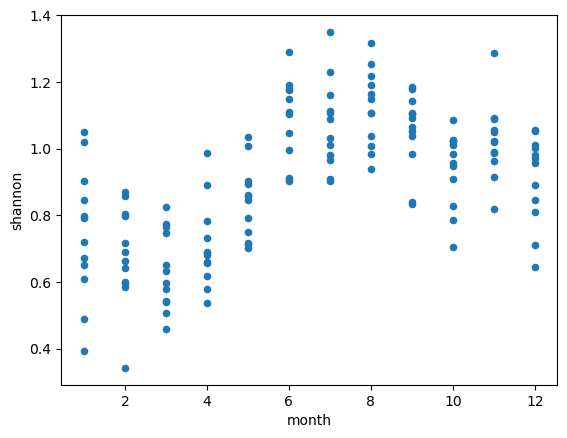

In [140]:
SDI_means.plot('month','shannon',kind='scatter')

C:\Users\Ajax\AppData\Local\Temp\ipykernel_45136\1446467906.py:2: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

C:\Users\Ajax\AppData\Local\Temp\ipykernel_45136\1446467906.py:6: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



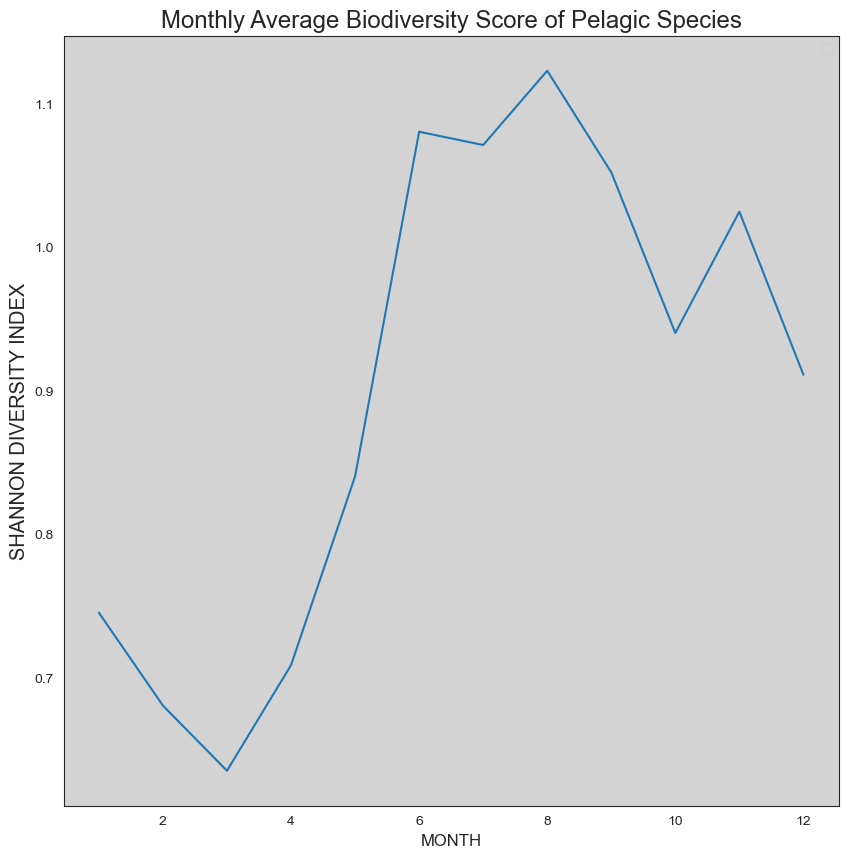

In [587]:
plt.figure(figsize=(10,10))
sns.lineplot(x='month',y='shannon',data=monthly_average,palette='viridis')
plt.title('Monthly Average Biodiversity Score of Pelagic Species',fontsize='xx-large')
plt.xlabel('MONTH',fontsize='large')
plt.ylabel('SHANNON DIVERSITY INDEX', fontsize='x-large')
plt.legend()
plt.show()

In [565]:
monthly_average_sdi=SDI_means.groupby('month').shannon.mean()

In [576]:
monthly_average=pd.DataFrame(monthly_average_sdi.reset_index())
monthly_average

,month,shannon
0,1,0.745361
1,2,0.680621
2,3,0.635257
3,4,0.708820
4,5,0.840306
5,6,1.080407
6,7,1.071142
7,8,1.122901
8,9,1.052118
9,10,0.940210


In [142]:
SDI_means_2['monthyr']=SDI_means_2.month.astype(str)+'_'+SDI_means_2.sgyear.astype(str)
SDI_means_2['ym']=SDI_means_2.sgyear.astype(str)+'_'+SDI_means_2.month.astype(str)
SDI_means_2

,month,sgyear,shannon,monthyr,ym
0,1,1999,0.489115,1_1999,1999_1
12,2,1999,0.859081,2_1999,1999_2
24,3,1999,0.825866,3_1999,1999_3
36,4,1999,0.783379,4_1999,1999_4
48,5,1999,0.894913,5_1999,1999_5
...,...,...,...,...,...
95,8,2022,0.985419,8_2022,2022_8
107,9,2022,1.037126,9_2022,2022_9
119,10,2022,0.909193,10_2022,2022_10
131,11,2022,0.818095,11_2022,2022_11


In [143]:
benX_match_nekton=benX_sindex[benX_sindex.Year.isin(years)]

In [144]:
benX_match_nekton

,Year,month,AreaAbbr,ShannonDiversity,Temp-T,Temp-B,ym
73,1999,8,AR,0.466296,29.028519,29.180000,1999-8
74,1999,8,HR,0.569000,28.804500,29.049500,1999-8
75,1999,8,PR,0.201000,30.941000,30.619500,1999-8
76,1999,8,TCB,0.517500,31.500000,31.250000,1999-8
77,1999,9,AR,0.486154,29.002308,29.672308,1999-9
...,...,...,...,...,...,...,...
392,2022,8,LTB,0.519500,30.422000,30.467500,2022-8
393,2022,8,MTB,0.542500,30.166250,30.077500,2022-8
394,2022,8,OTB,0.510000,30.475714,30.305714,2022-8
395,2022,9,MR,0.618750,29.317500,28.842500,2022-9


In [145]:
benX_match_nekton['year_seq']=benX_match_nekton.Year.map({
    1999:1,
    2001:2,
    2004:3,
    2006:4,
    2008:5,
    2010:6,
    2012:7,
    2014:8,
    2016:9,
    2018:10,
    2020:11,
    2022:12
    })

C:\Users\Ajax\AppData\Local\Temp\ipykernel_45136\1958726963.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [146]:
benX_match_nekton

,Year,month,AreaAbbr,ShannonDiversity,Temp-T,Temp-B,ym,year_seq
73,1999,8,AR,0.466296,29.028519,29.180000,1999-8,1
74,1999,8,HR,0.569000,28.804500,29.049500,1999-8,1
75,1999,8,PR,0.201000,30.941000,30.619500,1999-8,1
76,1999,8,TCB,0.517500,31.500000,31.250000,1999-8,1
77,1999,9,AR,0.486154,29.002308,29.672308,1999-9,1
...,...,...,...,...,...,...,...,...
392,2022,8,LTB,0.519500,30.422000,30.467500,2022-8,12
393,2022,8,MTB,0.542500,30.166250,30.077500,2022-8,12
394,2022,8,OTB,0.510000,30.475714,30.305714,2022-8,12
395,2022,9,MR,0.618750,29.317500,28.842500,2022-9,12


In [147]:
#year_seq=pd.Series()

In [148]:
year_seq=benX_match_nekton['year_seq'].astype(int)

In [149]:
benX_match_nekton['year_seq_month']=benX_match_nekton.year_seq.astype(str)+'_'+benX_match_nekton.month.astype(str)

C:\Users\Ajax\AppData\Local\Temp\ipykernel_45136\3808030496.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [150]:
benX_AreaMean=benX_match_nekton.groupby(['Year','month','year_seq_month']).ShannonDiversity.mean().reset_index()

In [151]:
benX_AreaMean.head(3)

,Year,month,year_seq_month,ShannonDiversity
0,1999,8,1_8,0.438449
1,1999,9,1_9,0.558688
2,1999,10,1_10,0.586418


In [152]:
benX_yrmonth=benX_match_nekton.year_seq.astype(str)+'_'+benX_match_nekton.month.astype(str)

In [153]:
benX_match_nekton.head(3)

,Year,month,AreaAbbr,ShannonDiversity,Temp-T,Temp-B,ym,year_seq,year_seq_month
73,1999,8,AR,0.466296,29.028519,29.1800,1999-8,1,1_8
74,1999,8,HR,0.569000,28.804500,29.0495,1999-8,1,1_8
75,1999,8,PR,0.201000,30.941000,30.6195,1999-8,1,1_8


In [154]:
benX_AreaMean

,Year,month,year_seq_month,ShannonDiversity
0,1999,8,1_8,0.438449
1,1999,9,1_9,0.558688
2,1999,10,1_10,0.586418
3,2001,5,2_5,0.571034
4,2001,7,2_7,0.418125
5,2001,8,2_8,0.532607
6,2001,9,2_9,0.536389
7,2001,10,2_10,0.580000
8,2004,3,3_3,0.640000
9,2004,4,3_4,0.590667


In [155]:
#############
NP_means
#############
## Sequencing years for Nit-Phos

,year,month,ym,Nit,Phos,ActivityDepth,Latitude,Longitude
0,1990,1,1990_1,0.682750,0.525385,2.319250,27.795134,-82.504102
1,1990,2,1990_2,0.847750,0.534000,2.451250,27.792931,-82.504449
2,1990,3,1990_3,0.641500,0.469091,2.362000,27.792931,-82.504449
3,1990,4,1990_4,0.630976,0.529375,2.224878,27.794969,-82.502239
4,1990,5,1990_5,0.676829,0.649000,2.543902,27.794969,-82.502239
...,...,...,...,...,...,...,...,...
411,2024,4,2024_4,0.442958,0.129429,2.052083,27.795194,-82.496064
412,2024,5,2024_5,0.330565,0.111750,2.039130,27.800788,-82.493325
413,2024,6,2024_6,0.355957,0.112889,2.219565,27.800788,-82.493325
414,2024,7,2024_7,0.182000,0.124333,2.494118,27.778137,-82.513610


In [156]:
NP_means['year_seq']=NP_means.year.map({
    1999:1,
    2001:2,
    2004:3,
    2006:4,
    2008:5,
    2010:6,
    2012:7,
    2014:8,
    2016:9,
    2018:10,
    2020:11,
    2022:12
    })

C:\Users\Ajax\AppData\Local\Temp\ipykernel_45136\3799716401.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [157]:
##Create a matching table for Nekton/Benthic
NP_match=NP_means[NP_means.year.isin(years)]

In [158]:
NP_match.shape

(144, 9)

In [159]:
SDI_means_2.shape

(144, 5)

In [160]:
benX_AreaMean.shape

(41, 4)

In [161]:
benX_sindex.Year.value_counts().count()

30

In [162]:
NP_match.year_seq=NP_match.year_seq.astype(int)

C:\Users\Ajax\AppData\Local\Temp\ipykernel_45136\2956619232.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [163]:
NP_match['ym_seq']=NP_match.year_seq.astype(str)+'_'+NP_match.month.astype(str)

C:\Users\Ajax\AppData\Local\Temp\ipykernel_45136\1873409731.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [164]:
NP_match.reset_index(drop=True,inplace=True)
SDI_means_2.reset_index(drop=True,inplace=True)
NP_match

,year,month,ym,Nit,Phos,ActivityDepth,Latitude,Longitude,year_seq,ym_seq
0,1999,1,1999_1,0.642960,0.155000,1.430417,27.818557,-82.497083,1,1_1
1,1999,2,1999_2,0.516667,0.217500,0.971111,27.812085,-82.487398,1,1_2
2,1999,3,1999_3,0.589455,0.227500,0.881905,27.803355,-82.518752,1,1_3
3,1999,4,1999_4,0.621739,0.248571,1.461739,27.823980,-82.498598,1,1_4
4,1999,5,1999_5,0.725000,0.171818,1.437778,27.816501,-82.488693,1,1_5
...,...,...,...,...,...,...,...,...,...,...
139,2022,8,2022_8,0.413314,0.121000,1.568571,27.798501,-82.522758,12,12_8
140,2022,9,2022_9,0.440909,0.241167,1.513636,27.798483,-82.520057,12,12_9
141,2022,10,2022_10,0.349529,0.376714,1.497059,27.790141,-82.519279,12,12_10
142,2022,11,2022_11,0.515480,0.114714,1.782000,27.804925,-82.486603,12,12_11


In [165]:
NP_nekton=pd.concat([NP_match,SDI_means_2.shannon],axis=1)
NP_nekton.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           144 non-null    int64  
 1   month          144 non-null    int64  
 2   ym             144 non-null    object 
 3   Nit            144 non-null    float64
 4   Phos           144 non-null    float64
 5   ActivityDepth  144 non-null    float64
 6   Latitude       144 non-null    float64
 7   Longitude      144 non-null    float64
 8   year_seq       144 non-null    int32  
 9   ym_seq         144 non-null    object 
 10  shannon        144 non-null    float64
dtypes: float64(6), int32(1), int64(2), object(2)
memory usage: 11.9+ KB


In [166]:
NP_nekton.index=NP_nekton.ym

In [167]:
NP_nekton

,year,month,ym,Nit,Phos,ActivityDepth,Latitude,Longitude,year_seq,ym_seq,shannon
ym,,,,,,,,,,,
1999_1,1999,1,1999_1,0.642960,0.155000,1.430417,27.818557,-82.497083,1,1_1,0.489115
1999_2,1999,2,1999_2,0.516667,0.217500,0.971111,27.812085,-82.487398,1,1_2,0.859081
1999_3,1999,3,1999_3,0.589455,0.227500,0.881905,27.803355,-82.518752,1,1_3,0.825866
1999_4,1999,4,1999_4,0.621739,0.248571,1.461739,27.823980,-82.498598,1,1_4,0.783379
1999_5,1999,5,1999_5,0.725000,0.171818,1.437778,27.816501,-82.488693,1,1_5,0.894913
...,...,...,...,...,...,...,...,...,...,...,...
2022_8,2022,8,2022_8,0.413314,0.121000,1.568571,27.798501,-82.522758,12,12_8,0.985419
2022_9,2022,9,2022_9,0.440909,0.241167,1.513636,27.798483,-82.520057,12,12_9,1.037126
2022_10,2022,10,2022_10,0.349529,0.376714,1.497059,27.790141,-82.519279,12,12_10,0.909193


In [168]:
NP_nekton=NP_nekton.iloc[:,[3,4,10]]

In [169]:
NP_nekton

,Nit,Phos,shannon
ym,,,
1999_1,0.642960,0.155000,0.489115
1999_2,0.516667,0.217500,0.859081
1999_3,0.589455,0.227500,0.825866
1999_4,0.621739,0.248571,0.783379
1999_5,0.725000,0.171818,0.894913
...,...,...,...
2022_8,0.413314,0.121000,0.985419
2022_9,0.440909,0.241167,1.037126
2022_10,0.349529,0.376714,0.909193


In [170]:
NP_means['date_format']=pd.to_datetime(NP_means.year.astype(str)+'-'+NP_means.month.astype(str)+'-01')

C:\Users\Ajax\AppData\Local\Temp\ipykernel_45136\1543762953.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [171]:
NP_means

,year,month,ym,Nit,Phos,ActivityDepth,Latitude,Longitude,year_seq,date_format
0,1990,1,1990_1,0.682750,0.525385,2.319250,27.795134,-82.504102,NaN,1990-01-01
1,1990,2,1990_2,0.847750,0.534000,2.451250,27.792931,-82.504449,NaN,1990-02-01
2,1990,3,1990_3,0.641500,0.469091,2.362000,27.792931,-82.504449,NaN,1990-03-01
3,1990,4,1990_4,0.630976,0.529375,2.224878,27.794969,-82.502239,NaN,1990-04-01
4,1990,5,1990_5,0.676829,0.649000,2.543902,27.794969,-82.502239,NaN,1990-05-01
...,...,...,...,...,...,...,...,...,...,...
411,2024,4,2024_4,0.442958,0.129429,2.052083,27.795194,-82.496064,NaN,2024-04-01
412,2024,5,2024_5,0.330565,0.111750,2.039130,27.800788,-82.493325,NaN,2024-05-01
413,2024,6,2024_6,0.355957,0.112889,2.219565,27.800788,-82.493325,NaN,2024-06-01
414,2024,7,2024_7,0.182000,0.124333,2.494118,27.778137,-82.513610,NaN,2024-07-01


In [465]:
import scipy.stats as stats
stats.ttest_rel(NP_means.Nit,NP_means.Phos)

TtestResult(statistic=26.69831956761394, pvalue=3.967183052940055e-92, df=415)

<Axes: >

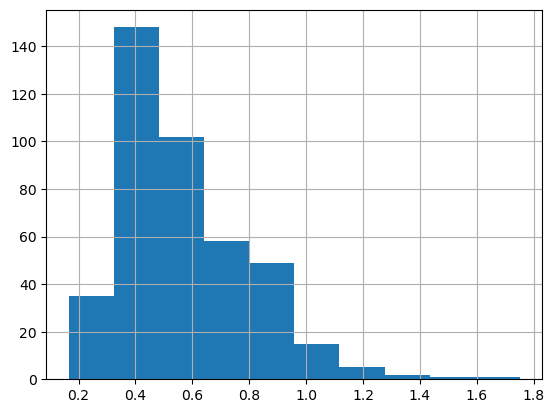

In [467]:
NP_means.Nit.hist()

<Axes: >

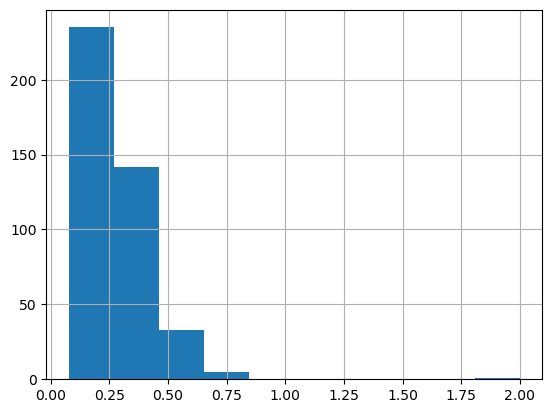

In [468]:
NP_means.Phos.hist()

In [172]:
Nitdecomp=pd.DataFrame(data=NP_means.Nit,index=NP_means.date_format)

In [174]:
Nitdecomp.Nit=NP_means.Nit

In [175]:
NP_means.Phos

0      0.525385
1      0.534000
2      0.469091
3      0.529375
4      0.649000
         ...   
411    0.129429
412    0.111750
413    0.112889
414    0.124333
415    0.342667
Name: Phos, Length: 416, dtype: float64

In [176]:
decomp_N=pd.DataFrame(data=NP_means.Nit,index=NP_means.date_format)
decomp_P=pd.DataFrame(data=NP_means.Phos,index=NP_means.date_format)
decomp_N.index.name=''
decomp_P.index.name=''

In [178]:
decomp_N=NP_means.Nit.to_frame()
decomp_P=NP_means.Phos.to_frame()

In [179]:
decomp_P.index=NP_means.date_format
decomp_P.index.name=''
decomp_P

,Phos
,
1990-01-01,0.525385
1990-02-01,0.534000
1990-03-01,0.469091
1990-04-01,0.529375
1990-05-01,0.649000
...,...
2024-04-01,0.129429
2024-05-01,0.111750
2024-06-01,0.112889


In [182]:
decomp_N.index=NP_means.date_format
decomp_N.index.name=''
decomp_N

,Nit
,
1990-01-01,0.682750
1990-02-01,0.847750
1990-03-01,0.641500
1990-04-01,0.630976
1990-05-01,0.676829
...,...
2024-04-01,0.442958
2024-05-01,0.330565
2024-06-01,0.355957


In [183]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [184]:
decomposition_N=seasonal_decompose(decomp_N,model='multiplicative')
decomposition_P=seasonal_decompose(decomp_P,model='multiplicative')


In [185]:
decomp_P['seasonal']=decomposition_P.seasonal
decomp_P['trend']=decomposition_P.trend
decomp_P['residual']=decomposition_P.resid

In [186]:
decomp_N['seasonal']=decomposition_N.seasonal
decomp_N['trend']=decomposition_N.trend
decomp_N['residual']=decomposition_N.resid

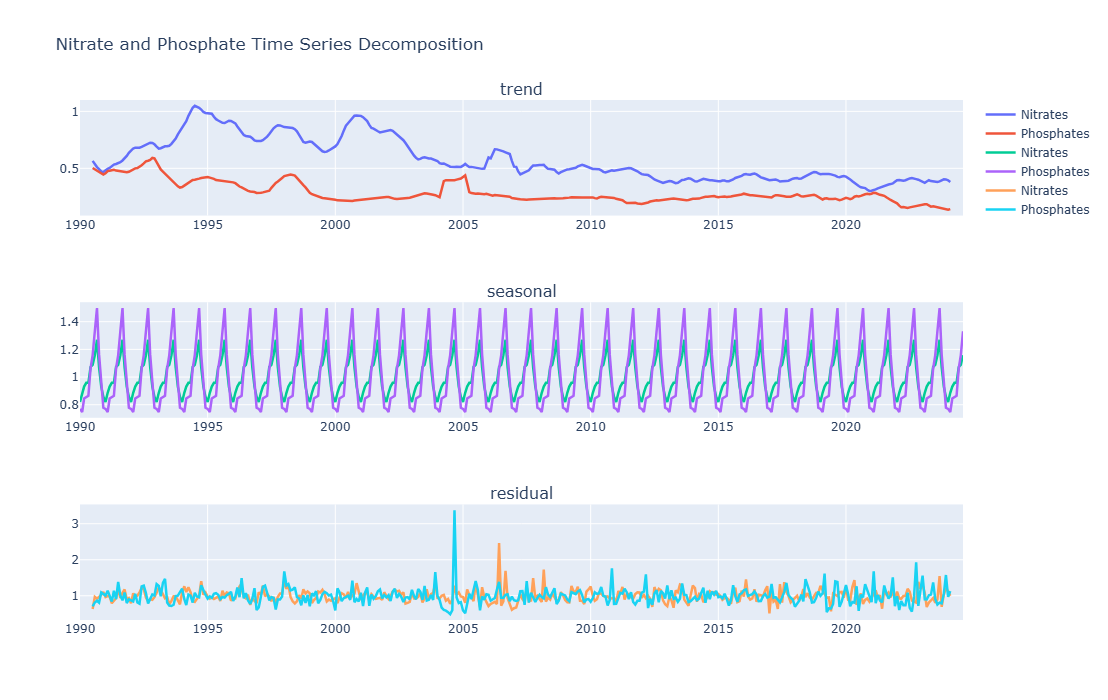

In [557]:
cols = ["trend", "seasonal", "residual"]

fig = make_subplots(rows=3, cols=1, subplot_titles=cols)

for i, col in enumerate(cols):
    fig.add_trace(
        go.Scatter(x=decomp_N.index, y=decomp_N[col],name='Nitrates'),
        row=i+1,
        col=1
    )
    fig.add_trace(
        go.Scatter(x=decomp_P.index, y=decomp_P[col],name='Phosphates'),
        row=i+1,
        col=1
    )

fig.update_layout(
    height=700,
    width=1000,
    showlegend=True,
    title=dict(text="Nitrate and Phosphate Time Series Decomposition"),
    font=dict(size=12),
#    yref='paper'
)

fig.update_traces(
    line=dict(dash="solid", width=2.5), line_shape='linear'
    )

#fig.suptitle()
fig.show()

In [189]:
NP_nekton

,Nit,Phos,shannon
ym,,,
1999_1,0.642960,0.155000,0.489115
1999_2,0.516667,0.217500,0.859081
1999_3,0.589455,0.227500,0.825866
1999_4,0.621739,0.248571,0.783379
1999_5,0.725000,0.171818,0.894913
...,...,...,...
2022_8,0.413314,0.121000,0.985419
2022_9,0.440909,0.241167,1.037126
2022_10,0.349529,0.376714,0.909193


In [191]:
benX_match_nekton

,Year,month,AreaAbbr,ShannonDiversity,Temp-T,Temp-B,ym,year_seq,year_seq_month
73,1999,8,AR,0.466296,29.028519,29.180000,1999-8,1,1_8
74,1999,8,HR,0.569000,28.804500,29.049500,1999-8,1,1_8
75,1999,8,PR,0.201000,30.941000,30.619500,1999-8,1,1_8
76,1999,8,TCB,0.517500,31.500000,31.250000,1999-8,1,1_8
77,1999,9,AR,0.486154,29.002308,29.672308,1999-9,1,1_9
...,...,...,...,...,...,...,...,...,...
392,2022,8,LTB,0.519500,30.422000,30.467500,2022-8,12,12_8
393,2022,8,MTB,0.542500,30.166250,30.077500,2022-8,12,12_8
394,2022,8,OTB,0.510000,30.475714,30.305714,2022-8,12,12_8
395,2022,9,MR,0.618750,29.317500,28.842500,2022-9,12,12_9


NameError: name 'nit' is not defined

In [478]:
NP_match

,year,month,ym,Nit,Phos,ActivityDepth,Latitude,Longitude,year_seq,ym_seq
0,1999,1,1999_1,0.642960,0.155000,1.430417,27.818557,-82.497083,1,1_1
1,1999,2,1999_2,0.516667,0.217500,0.971111,27.812085,-82.487398,1,1_2
2,1999,3,1999_3,0.589455,0.227500,0.881905,27.803355,-82.518752,1,1_3
3,1999,4,1999_4,0.621739,0.248571,1.461739,27.823980,-82.498598,1,1_4
4,1999,5,1999_5,0.725000,0.171818,1.437778,27.816501,-82.488693,1,1_5
5,1999,6,1999_6,0.775476,0.230769,1.260000,27.825173,-82.493675,1,1_6
6,1999,7,1999_7,0.823913,0.290000,1.816522,27.819636,-82.491273,1,1_7
7,1999,8,1999_8,0.778421,0.348889,1.303158,27.831165,-82.494914,1,1_8
8,1999,9,1999_9,0.689318,0.377692,2.067727,27.792488,-82.511576,1,1_9
9,1999,10,1999_10,0.629000,0.269333,2.298864,27.792711,-82.515179,1,1_10


In [ ]:
SDI_means_2

In [506]:
SDI_means_2['day']='01'

SyntaxError: invalid syntax (4030355018.py, line 1)

In [509]:
NP_match['day']='01'

C:\Users\Ajax\AppData\Local\Temp\ipykernel_45136\1831465455.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [510]:
NP_match

,year,month,ym,Nit,Phos,ActivityDepth,Latitude,Longitude,year_seq,ym_seq,day
0,1999,1,1999_1,0.642960,0.155000,1.430417,27.818557,-82.497083,1,1_1,01
1,1999,2,1999_2,0.516667,0.217500,0.971111,27.812085,-82.487398,1,1_2,01
2,1999,3,1999_3,0.589455,0.227500,0.881905,27.803355,-82.518752,1,1_3,01
3,1999,4,1999_4,0.621739,0.248571,1.461739,27.823980,-82.498598,1,1_4,01
4,1999,5,1999_5,0.725000,0.171818,1.437778,27.816501,-82.488693,1,1_5,01
5,1999,6,1999_6,0.775476,0.230769,1.260000,27.825173,-82.493675,1,1_6,01
6,1999,7,1999_7,0.823913,0.290000,1.816522,27.819636,-82.491273,1,1_7,01
7,1999,8,1999_8,0.778421,0.348889,1.303158,27.831165,-82.494914,1,1_8,01
8,1999,9,1999_9,0.689318,0.377692,2.067727,27.792488,-82.511576,1,1_9,01
9,1999,10,1999_10,0.629000,0.269333,2.298864,27.792711,-82.515179,1,1_10,01


In [505]:
NP_match['date_format']=pd.to_datetime(NP_match.day.astype(str)+'-'+NP_match.month.astype(str)+'-'+NP_match.year.astype(str))

AttributeError: 'DataFrame' object has no attribute 'day'

In [501]:
SDI_means_2['date_format'] = pd.to_datetime(SDI_means_2.day.astype(str)+'-'+SDI_means_2.month.astype(str)+'-'+SDI_means_2.sgyear.astype(str))

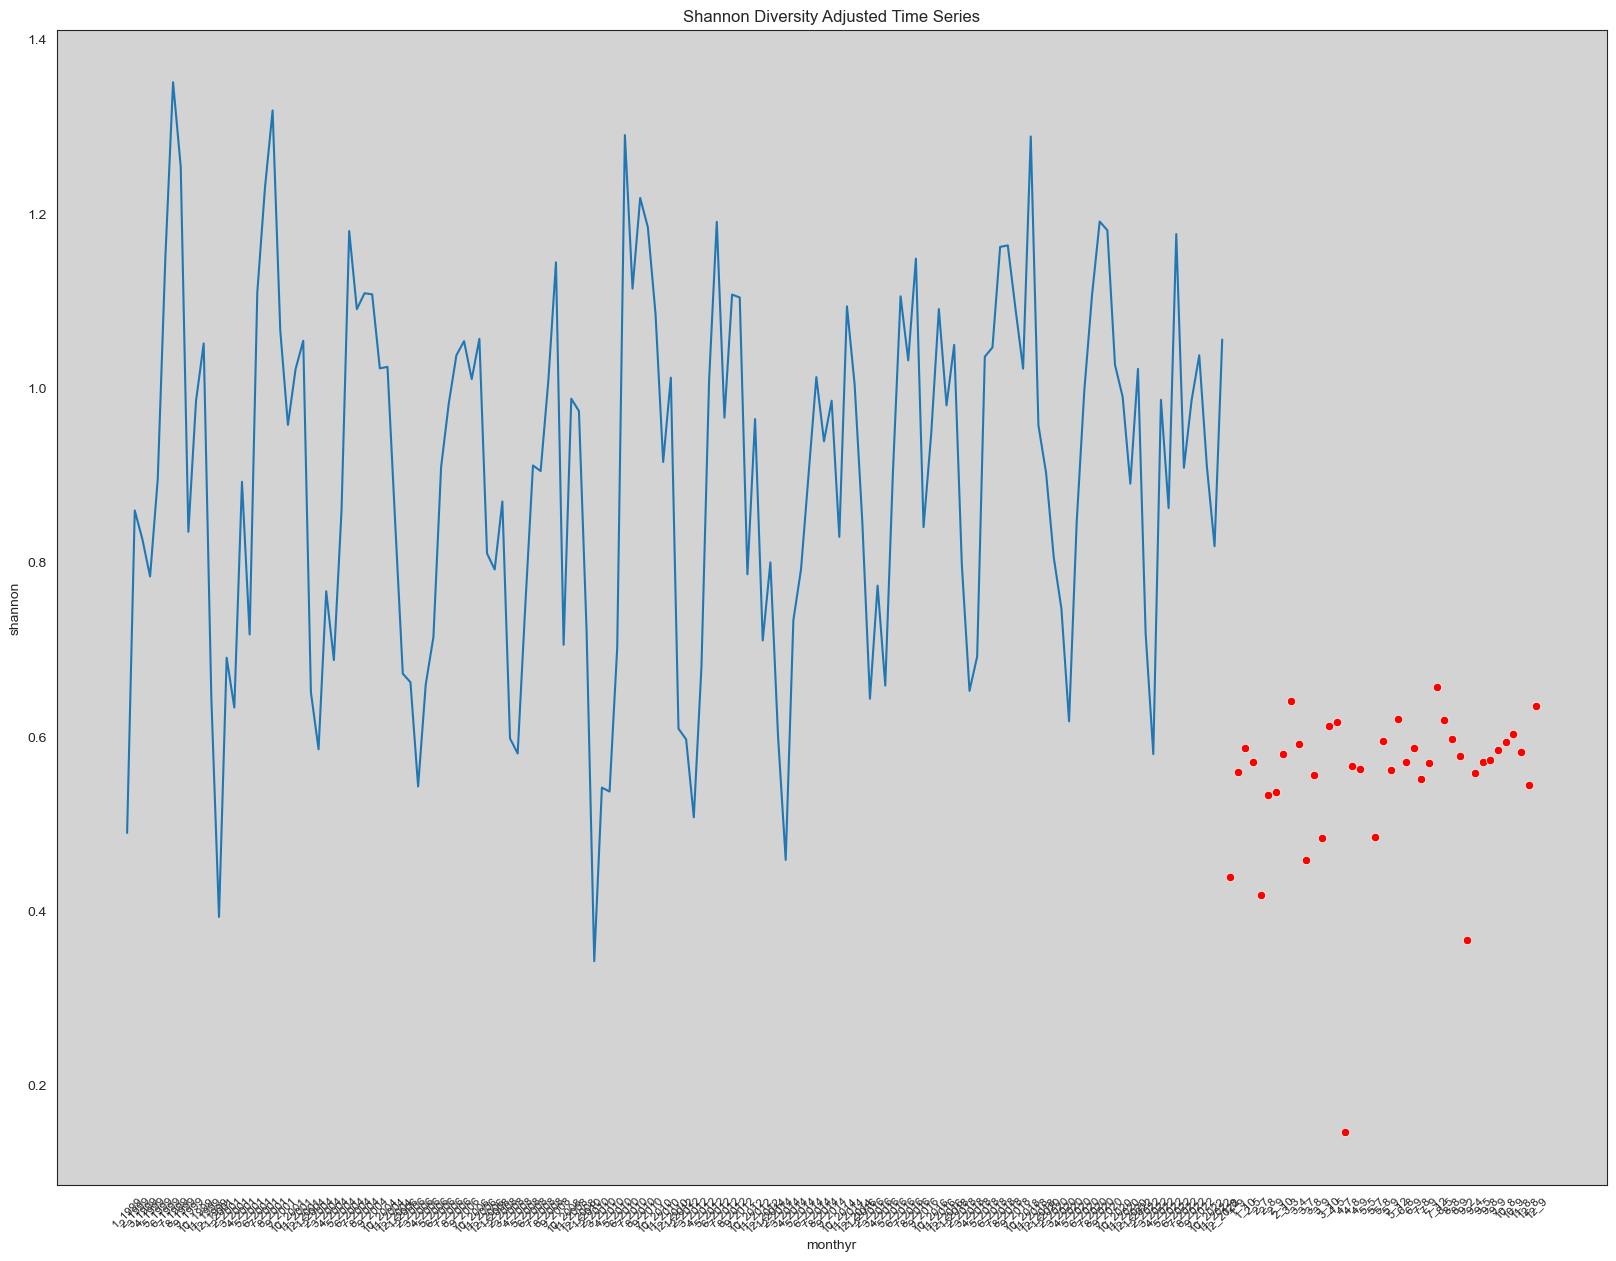

In [598]:
#plt.figure()
#sns.lineplot(x='monthyr',y='shannon',data=SDI_means_2,palette='viridis')
fig,ax=plt.subplots(figsize=(20,15))
plt.subplot()
sns.lineplot(x='monthyr',y='shannon',data=SDI_means_2,ax=ax)
plt.subplot()
sns.scatterplot(x='year_seq_month',y='ShannonDiversity', data=benX_AreaMean,color='red')
#plt.legend()
plt.xticks(rotation=45,fontsize='small')
plt.title('Shannon Diversity Adjusted Time Series')
plt.show()

In [474]:
benX_sindex['yrmon']=benX_sindex.month.astype(str)+'_'+benX_sindex.Year.astype(str)

<Axes: title={'center': 'Benthic SDI Adjusted for Sampling Schedule'}, xlabel='ym'>

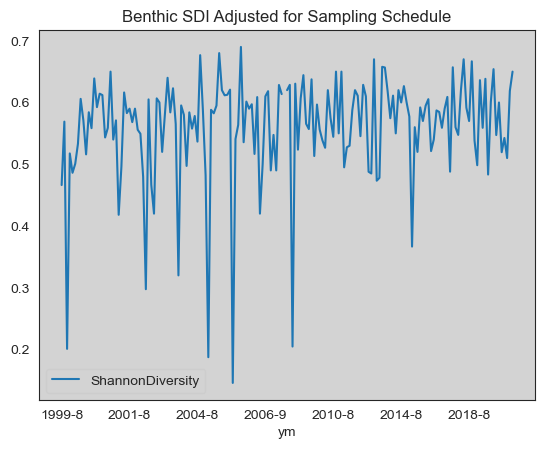

In [600]:
benX_sindex[benX_sindex.Year.isin(years)].plot(x='ym',y='ShannonDiversity',title='Benthic SDI Adjusted for Sampling Schedule')

In [478]:
benX_sindex['year_seq']=benX_sindex.Year.map({
    1999:1,
    2001:2,
    2004:3,
    2006:4,
    2008:5,
    2010:6,
    2012:7,
    2014:8,
    2016:9,
    2018:10,
    2020:11,
    2022:12
    })

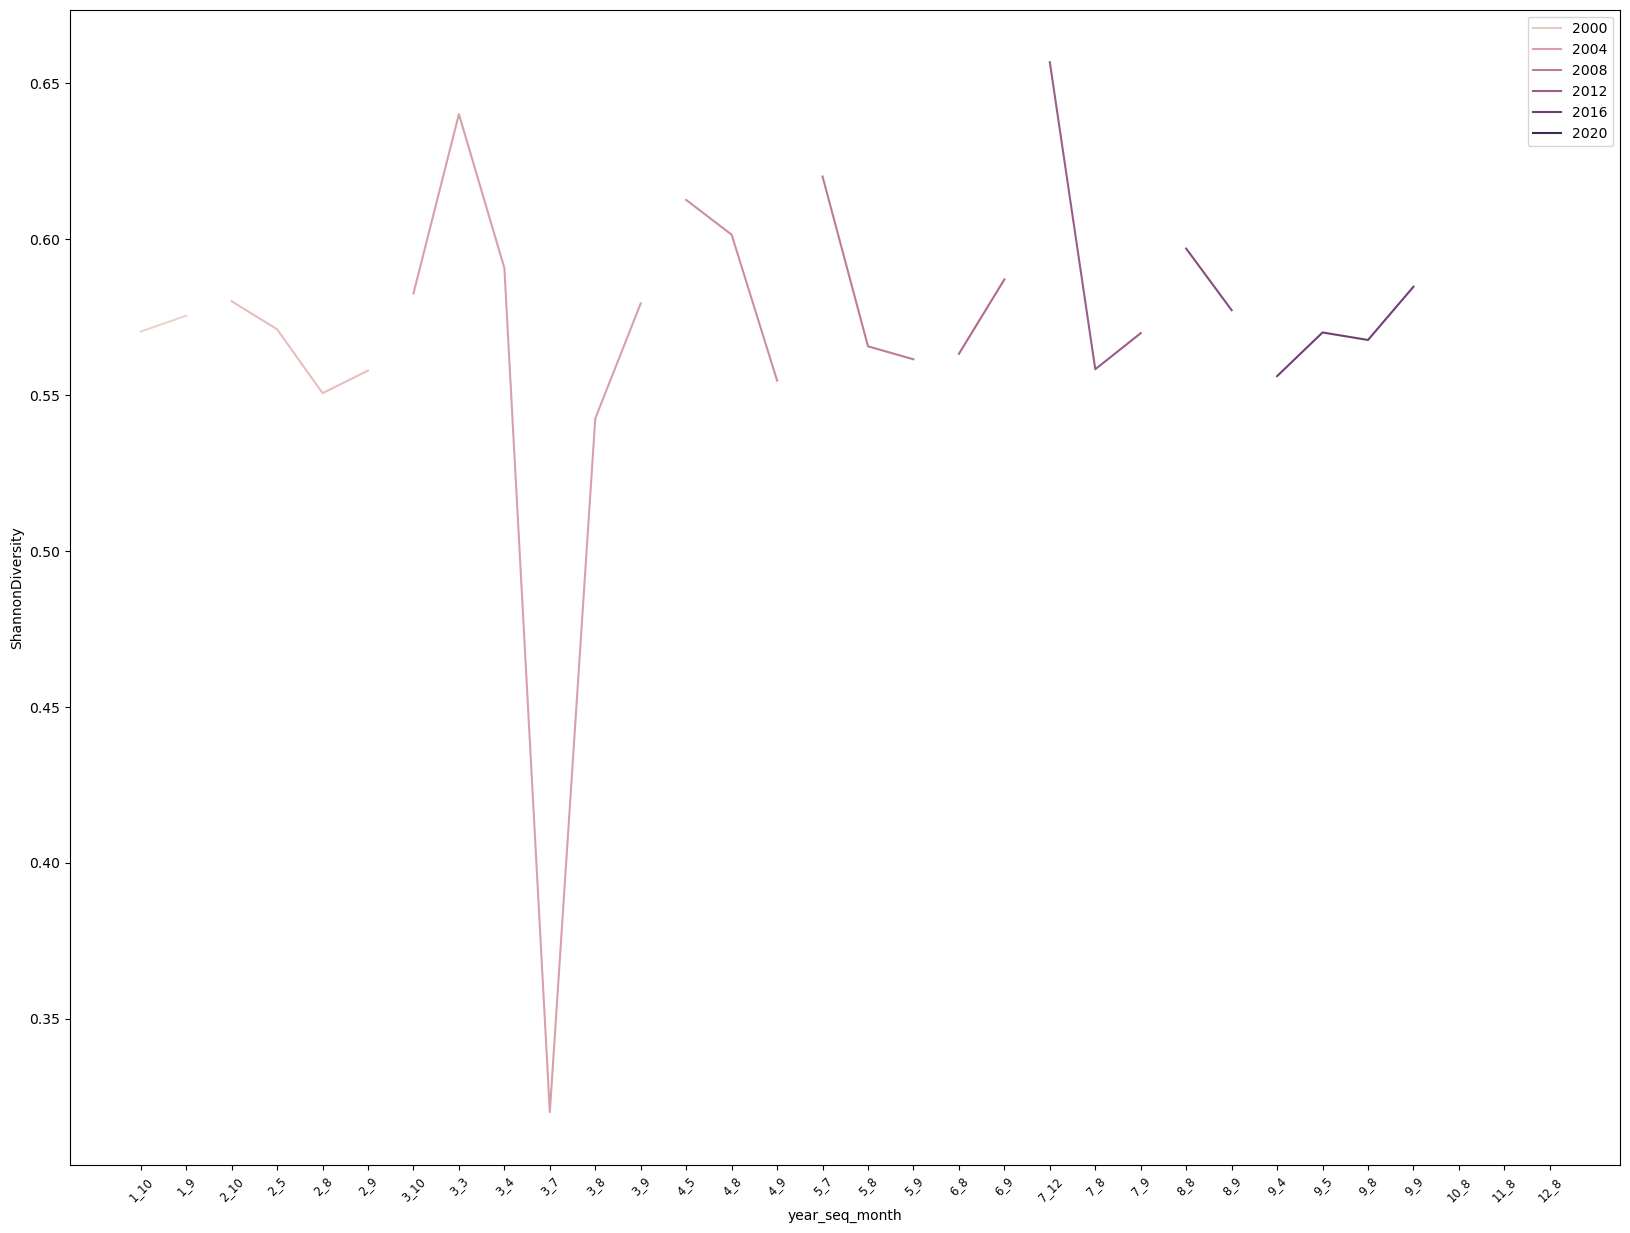

In [520]:
plt.figure(figsize=(20,15))
sns.lineplot(x='year_seq_month',y='ShannonDiversity', data=benX_AreaMean , hue='Year')
plt.legend()
plt.xticks(rotation=45,fontsize='small')
plt.show()

In [ ]:
plt.figure(figsize=(20,15))
sns.lineplot(x='year_seq',y='shannon',data=SDI_means_2,palette='viridis')
plt.legend()1
plt.xticks(rotation=45,fontsize='small')
plt.show()

In [547]:
benX_AreaMean

,Year,year_seq_month,ShannonDiversity
0,1999,1_10,0.570296
1,1999,1_9,0.575365
2,2001,2_10,0.580000
3,2001,2_5,0.571034
4,2001,2_8,0.550540
5,2001,2_9,0.557778
6,2004,3_10,0.582500
7,2004,3_3,0.640000
8,2004,3_4,0.590667
9,2004,3_7,0.320000


In [524]:
shared_months=benX_match_nekton['year_seq_month']

In [549]:
SDI_means_2

,month,sgyear,shannon,monthyr
0,1,1,0.489115,1_1
12,2,1,0.859081,2_1
24,3,1,0.825866,3_1
36,4,1,0.783379,4_1
48,5,1,0.894913,5_1
...,...,...,...,...
95,8,12,0.985419,8_12
107,9,12,1.037126,9_12
119,10,12,0.909193,10_12
131,11,12,0.818095,11_12


In [545]:
benX_AreaMean[benX_AreaMean.year_seq_month.isin(shared_months)].shape

(32, 3)

In [552]:
test=SDI_means_2.merge(benX_AreaMean[benX_AreaMean.year_seq_month.isin(shared_months)], left_on='monthyr', right_on='year_seq_month')

<Axes: xlabel='year_seq_month'>

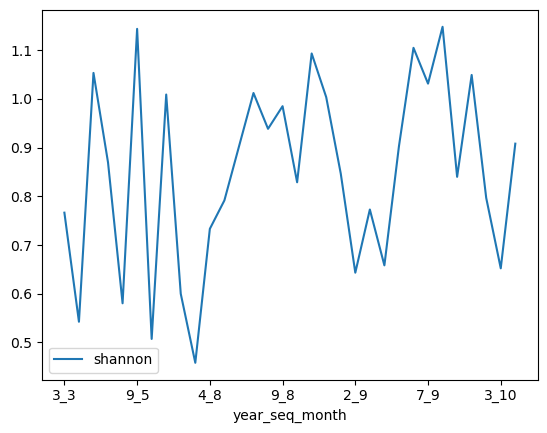

In [555]:
test.plot(x='year_seq_month',y='shannon')

C:\Users\Ajax\AppData\Local\Temp\ipykernel_34704\193213966.py:3: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



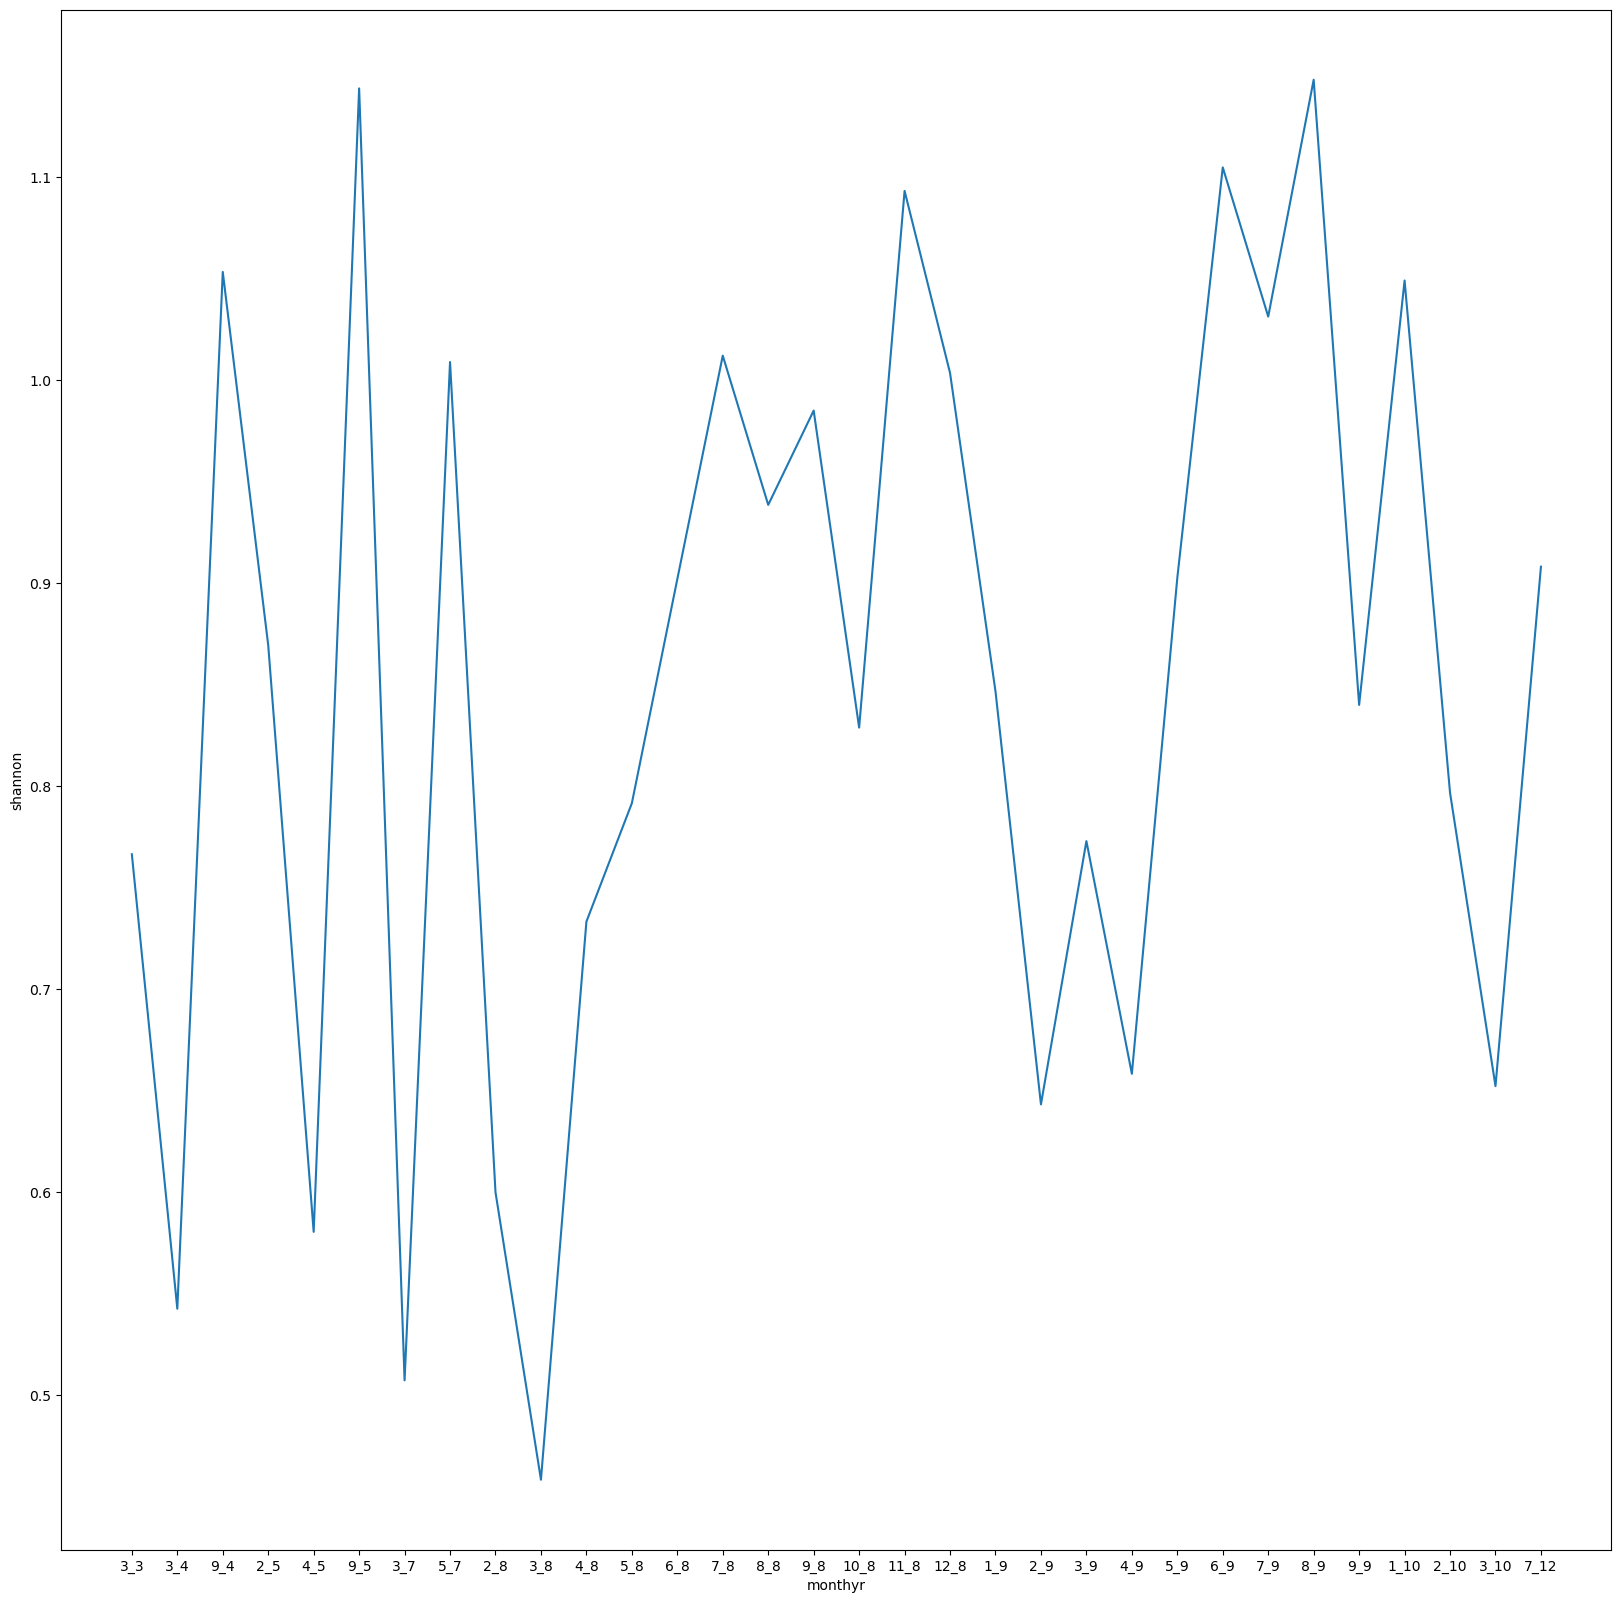

In [565]:
plt.figure(figsize=(20,20))
sns.lineplot(x='year_seq_month',y='ShannonDiversity', data=test,ax=ax)
sns.lineplot(x='monthyr',y='shannon',data=test,palette='viridis')
plt.show()

# Benthic with missing values

In [ ]:
# NP_means

In [193]:
os.chdir('J:\\Brainstation\\Capstone Git\\data\\PossibleDataSources\\Benthic Index\\OG_Results')

In [219]:
benthic_base=pd.read_csv('Benthic_BioDataSpreadsheet_ActualValuesCommunityStats2.csv',encoding='cp1252', low_memory=False)

In [220]:
benthic_base.head(4)

,ProgramAbbrev,ProgramName,FundingProject,AreaAbbr,AreaName,Hexagon,Year,SampleTime,StationID,StationNumber,Latitude,Longitude,Comments,Temp-T,TempQ-T,Temp-B,TempQ-B,DO-T,DOQ-T,DO-B,DOQ-B,DO-BCat,DOp-T,DOpQ-T,DOp-B,DOpQ-B,Cond-T,CondQ-T,Cond-B,CondQ-B,pH-T,pHQ-T,pH-B,pHQ-B,Sal-T,SalQ-T,Sal-B,SalQ-B,Salinity-BCat,Transmitter ID Number,Display ID Number,Depth-T,DepthQ-T,Depth-B,DepthQ-B,Depth-BCat,SiltClayPercent,SiltClay_Q,SiltClayCat,OrganicsCollected,A_BHC,A_BHC_Q,B_BHC,B_BHC_Q,D_BHC,D_BHC_Q,G_BHC,G_BHC_Q,Aldrin,Aldrin_Q,Dieldrin,Dieldrin_Q,Endrin,Endrin_Q,Endosulfan_I,Endosulfan_I_Q,Endosulfan_II,Endosulfan_II_Q,Heptachlor,Heptachlor_Q,Heptachlor_Epoxide,Heptachlor_Epoxide_Q,DDD,DDD_Q,DDE,DDE_Q,DDT,DDT_Q,Endrin_Aldehyde,Endrin_Aldehyde_Q,Endosulfan_SO4,Endosulfan_SO4_Q,Methoxychlor,Methoxychlor_Q,Endrin_Ketone,Endrin_Ketone_Q,Mirex,Mirex_Q,A_Chlordane,A_Chlordane_Q,G_Chlordane,G_Chlordane_Q,Total_Chlordane,Total_Chlordane_Q,PCB_8,PCB_8_Q,PCB_18,PCB_18_Q,PCB_28,PCB_28_Q,PCB_44,PCB_44_Q,PCB_52,PCB_52_Q,PCB_66,PCB_66_Q,PCB_101,PCB_101_Q,PCB_105,PCB_105_Q,PCB_118,PCB_118_Q,PCB_128,PCB_128_Q,PCB_153,PCB_153_Q,PCB_170,PCB_170_Q,PCB_180,PCB_180_Q,PCB_187,PCB_187_Q,PCB_195,PCB_195_Q,PCB_206,PCB_206_Q,PCB_1016,PCB_1016_Q,PCB_1221,PCB_1221_Q,PCB_1232,PCB_1232_Q,PCB_1242,PCB_1242_Q,PCB_1248,PCB_1248_Q,PCB_1254,PCB_1254_Q,PCB_1260,PCB_1260_Q,PCB_1262,PCB_1262_Q,PCB_1268,PCB_1268_Q,Acenaphthene,Acenaphthene_Q,Acenaphthylene,Acenaphthylene_Q,Anthracene,Anthracene_Q,Fluorene,Fluorene_Q,Naphthalene,Naphthalene_Q,Phenanthrene,Phenanthrene_Q,Benzo(a)anthracene,Benzo(a)anthracene_Q,Benzo(a)pyrene,Benzo(a)pyrene_Q,Chrysene,Chrysene_Q,"Dibenzo(a,h)anthracene","Dibenzo(a,h)anthracene_Q",Fluoranthene,Fluoranthene_Q,Pyrene,Pyrene_Q,Benzo(b)fluoranthene,Benzo(b)fluoranthene_Q,Benzo(k)fluoranthene,Benzo(k)fluoranthene_Q,"Indeno(1,2,3-c,d)pyrene","Indeno(1,2,3-c,d)pyrene_Q","Benzo(g,h,i)perylene","Benzo(g,h,i)perylene_Q",Retene,Retene_Q,Coronene,Coronene_Q,MetalsCollected,Aluminum,Aluminum_Q,Antimony,Antimony_Q,Arsenic,Arsenic_Q,Cadmium,Cadmium_Q,Chromium,Chromium_Q,Copper,Copper_Q,Iron,Iron_Q,Lead,Lead_Q,Manganese,Manganese_Q,Nickel,Nickel_Q,Selenium,Selenium_Q,Silver,Silver_Q,Tin,Tin_Q,Zinc,Zinc_Q,Mercury,Mercury_Q,TOC,TOC_Q,Total_Carbon,Total_Carbon_Q,Inorganic_Carbon,Inorganic_Carbon_Q,TBBI,TBBICat,SpeciesRichness,AdjCountAbundance,ShannonDiversity,DomSpecies1,DomSpecies1RelAbund,DomSpecies2,DomSpecies2RelAbund,ProgramId
0,Benthic,Benthic Monitoring,TBEP ...,HB,Hillsborough Bay,HB34,1993,9/14/93 11:33,2452,93HB03,27.874001,-82.418999,"3RD GRAB DESC: MUD, RPD = 0, SAV = N, TIME OF ...",29.31,NaN,29.30,NaN,6.39,NaN,5.42,NaN,Normoxic,95.0,C,80.7,C,NaN,NaN,NaN,NaN,7.88,NaN,7.85,NaN,23.4,NaN,23.7,NaN,Polyhaline,NaN,NaN,0.1,NaN,3.00,NaN,Deep Subtidal,NaN,O,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.84,Degraded,8.0,275.0,0.66,Paraprionospio sp.,0.272727,Sigambra tentaculata,0.181818,4
1,Benthic,Benthic Monitoring,TBEP ...,HB,Hillsborough Bay,HB26,1993,9/13/93 12:37,2453,93HB04,27.875000,-82.468002,"3RD GRAB DESC: MUDDY OOZE, RPD = 0, SAV = N, T...",29.89,NaN,29.36,NaN,7.85,NaN,5.31,NaN,Normoxic,116.6,C,78.5,C,NaN,NaN,NaN,NaN,8.03,NaN,7.92,NaN,21.4,NaN,22.2,NaN,Polyhaline,NaN,NaN,0.1,NaN,3.60,NaN,Deep Subtidal,20.7,NaN,Very Fine,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [221]:
benthic_base['month']=pd.to_datetime(benthic_base.SampleTime,format='mixed').dt.month

In [ ]:
# Determining which columns to keep
# 3,4,6,227,6,10,11,217,219,220,221
counter=0
for x in benthic_base.columns:
    print(f'[{counter}]: {x}')
    counter+=1

In [224]:
benthic=benthic_base.iloc[:,[3,4,6,227,10,11,217,219,220,221]]

In [227]:
benthic['date_format']=pd.to_datetime(benthic.Year.astype(str)+'-'+benthic.month.astype(str)+'-01')

C:\Users\Ajax\AppData\Local\Temp\ipykernel_45136\1132599771.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [228]:
benthic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4787 entries, 0 to 4786
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   AreaAbbr           4787 non-null   object        
 1   AreaName           4787 non-null   object        
 2   Year               4787 non-null   int64         
 3   month              4787 non-null   int32         
 4   Latitude           4787 non-null   float64       
 5   Longitude          4787 non-null   float64       
 6   TBBI               4568 non-null   float64       
 7   SpeciesRichness    4568 non-null   float64       
 8   AdjCountAbundance  4568 non-null   float64       
 9   ShannonDiversity   4568 non-null   float64       
 10  date_format        4787 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(6), int32(1), int64(1), object(2)
memory usage: 392.8+ KB


In [229]:
benthic.head(5)

,AreaAbbr,AreaName,Year,month,Latitude,Longitude,TBBI,SpeciesRichness,AdjCountAbundance,ShannonDiversity,date_format
0,HB,Hillsborough Bay,1993,9,27.874001,-82.418999,68.84,8.0,275.0,0.66,1993-09-01
1,HB,Hillsborough Bay,1993,9,27.875000,-82.468002,57.33,9.0,8175.0,0.29,1993-09-01
2,HB,Hillsborough Bay,1993,9,27.867001,-82.485001,66.98,53.0,19425.0,0.62,1993-09-01
3,HB,Hillsborough Bay,1993,9,27.858000,-82.474999,15.18,56.0,24225.0,0.65,1993-09-01
4,HB,Hillsborough Bay,1993,9,27.850201,-82.454002,63.30,12.0,350.0,0.56,1993-09-01


In [242]:
# Get subset for Hillsborough and Middle Tampa Bay
benthic_MTBHB=benthic[benthic.AreaAbbr.isin(['MTB','HB'])]

In [246]:
benthic_mean=benthic_MTBHB.groupby('date_format')[['SpeciesRichness','AdjCountAbundance','ShannonDiversity']].mean()

In [249]:
benthic_mean.index.name=''

In [252]:
benthic_mean.rename(columns={
    'SpeciesRichness':'benthic_SpeciesRichness',
    'AdjCountAbundance':'benthic_AdjCountAbundance',
    'ShannonDiversity':'benthic_shannon'
},inplace=True)

In [255]:
benthic_mean.shape

(59, 3)

In [258]:
benthic_mean.sort_index(inplace=True)

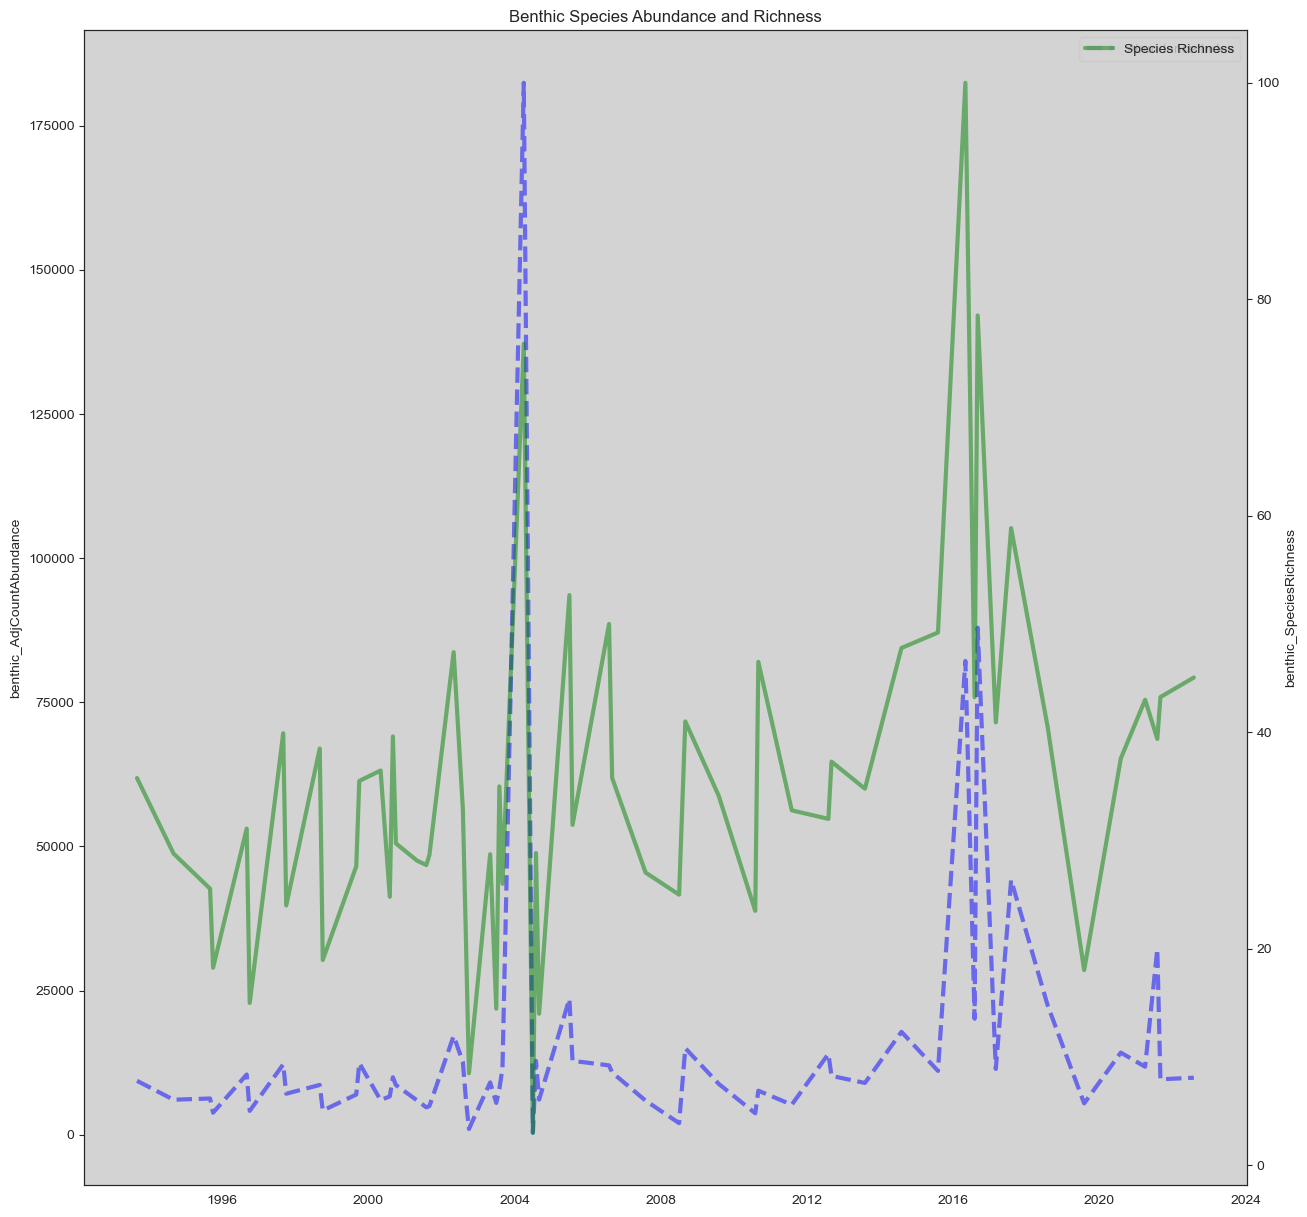

In [591]:
fig,ax= plt.subplots(figsize=(15,15))
plt.gca()
sns.lineplot(data=benthic_mean,x=benthic_mean.index,y='benthic_AdjCountAbundance',label='Abundance Index',ax=ax,color='blue',alpha=0.5,linestyle='--',linewidth=3)
plt.legend()
plt.gca()
ax1=ax.twinx()
sns.lineplot(data=benthic_mean,x=benthic_mean.index,y='benthic_SpeciesRichness',label='Species Richness',ax=ax1,color='green',alpha=0.5,linewidth=3)
plt.title('Benthic Species Abundance and Richness')
plt.xlabel('Year',fontsize='x-large')
plt.legend()
plt.show()

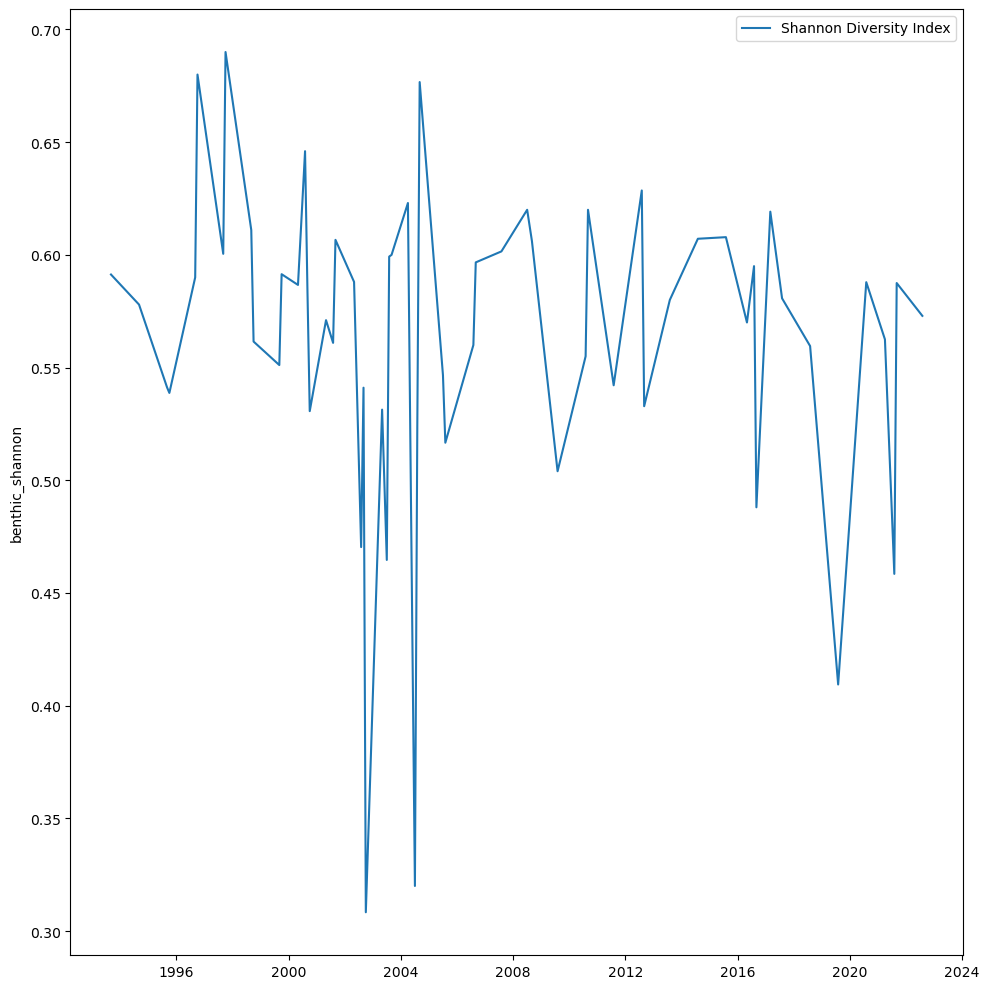

In [269]:
plt.figure(figsize=(10,10))
sns.lineplot(data=benthic_mean,x=benthic_mean.index,y='benthic_shannon',label='Shannon Diversity Index')
#sns.lineplot(data=benthic_mean,x=benthic_mean.index,y='benthic_AdjCountAbundance',label='Abundance Index')
#sns.lineplot(data=benthic_mean,x=benthic_mean.index,y='benthic_SpeciesRichness',label='Species Richness')
plt.tight_layout()

In [290]:
benthic_mean

,benthic_SpeciesRichness,benthic_AdjCountAbundance,benthic_shannon
,,,
1993-09-01,35.769231,9358.512821,0.591282
1994-09-01,28.794872,6082.307692,0.577949
1995-09-01,25.547619,6291.785714,0.541190
1995-10-01,18.250000,3831.250000,0.538750
1996-09-01,31.100000,10447.080000,0.590000
1996-10-01,15.000000,4150.000000,0.680000
1997-09-01,39.906977,12207.604651,0.600465
1997-10-01,24.000000,7125.000000,0.690000
1998-09-01,38.500000,8643.000000,0.611000


In [ ]:
benthic

In [292]:
benthic_corr=benthic.iloc[:,[2,3,4,5,6.7,8,9]]

In [ ]:
benthic_corr

In [294]:
benthic_corr.corr()

,Year,month,Latitude,Longitude,TBBI,AdjCountAbundance,ShannonDiversity
Year,1.000000,-0.306371,-0.023573,-0.155812,0.072688,0.153119,0.031738
month,-0.306371,1.000000,-0.201268,-0.157799,-0.042188,-0.200360,0.012543
Latitude,-0.023573,-0.201268,1.000000,0.404632,-0.179895,-0.104505,-0.112892
Longitude,-0.155812,-0.157799,0.404632,1.000000,-0.226991,-0.124496,-0.092236
TBBI,0.072688,-0.042188,-0.179895,-0.226991,1.000000,0.249296,0.514894
AdjCountAbundance,0.153119,-0.200360,-0.104505,-0.124496,0.249296,1.000000,0.095360
ShannonDiversity,0.031738,0.012543,-0.112892,-0.092236,0.514894,0.095360,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

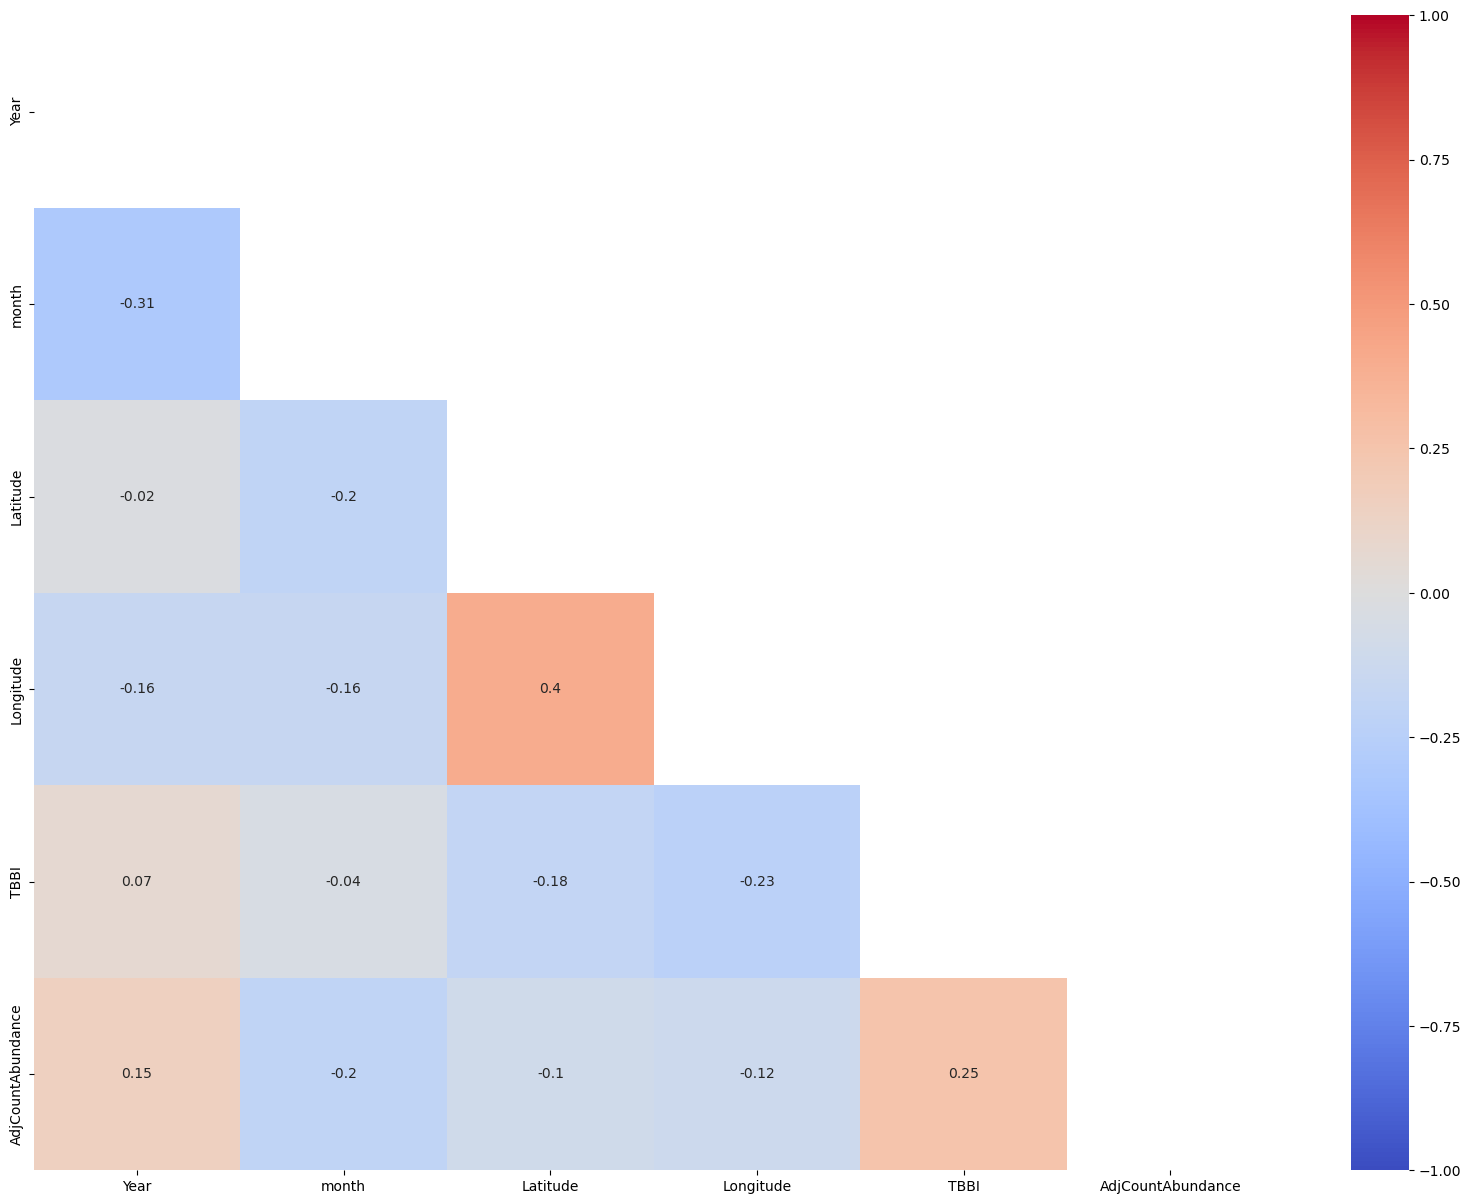

In [299]:
corr=benthic_corr.drop(columns='ShannonDiversity').corr()
mask=np.triu(corr)
plt.figure(figsize=(20,15))
sns.heatmap(corr.round(2), vmax=1,vmin=-1,center=0,cmap='coolwarm',mask=mask, annot=True)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

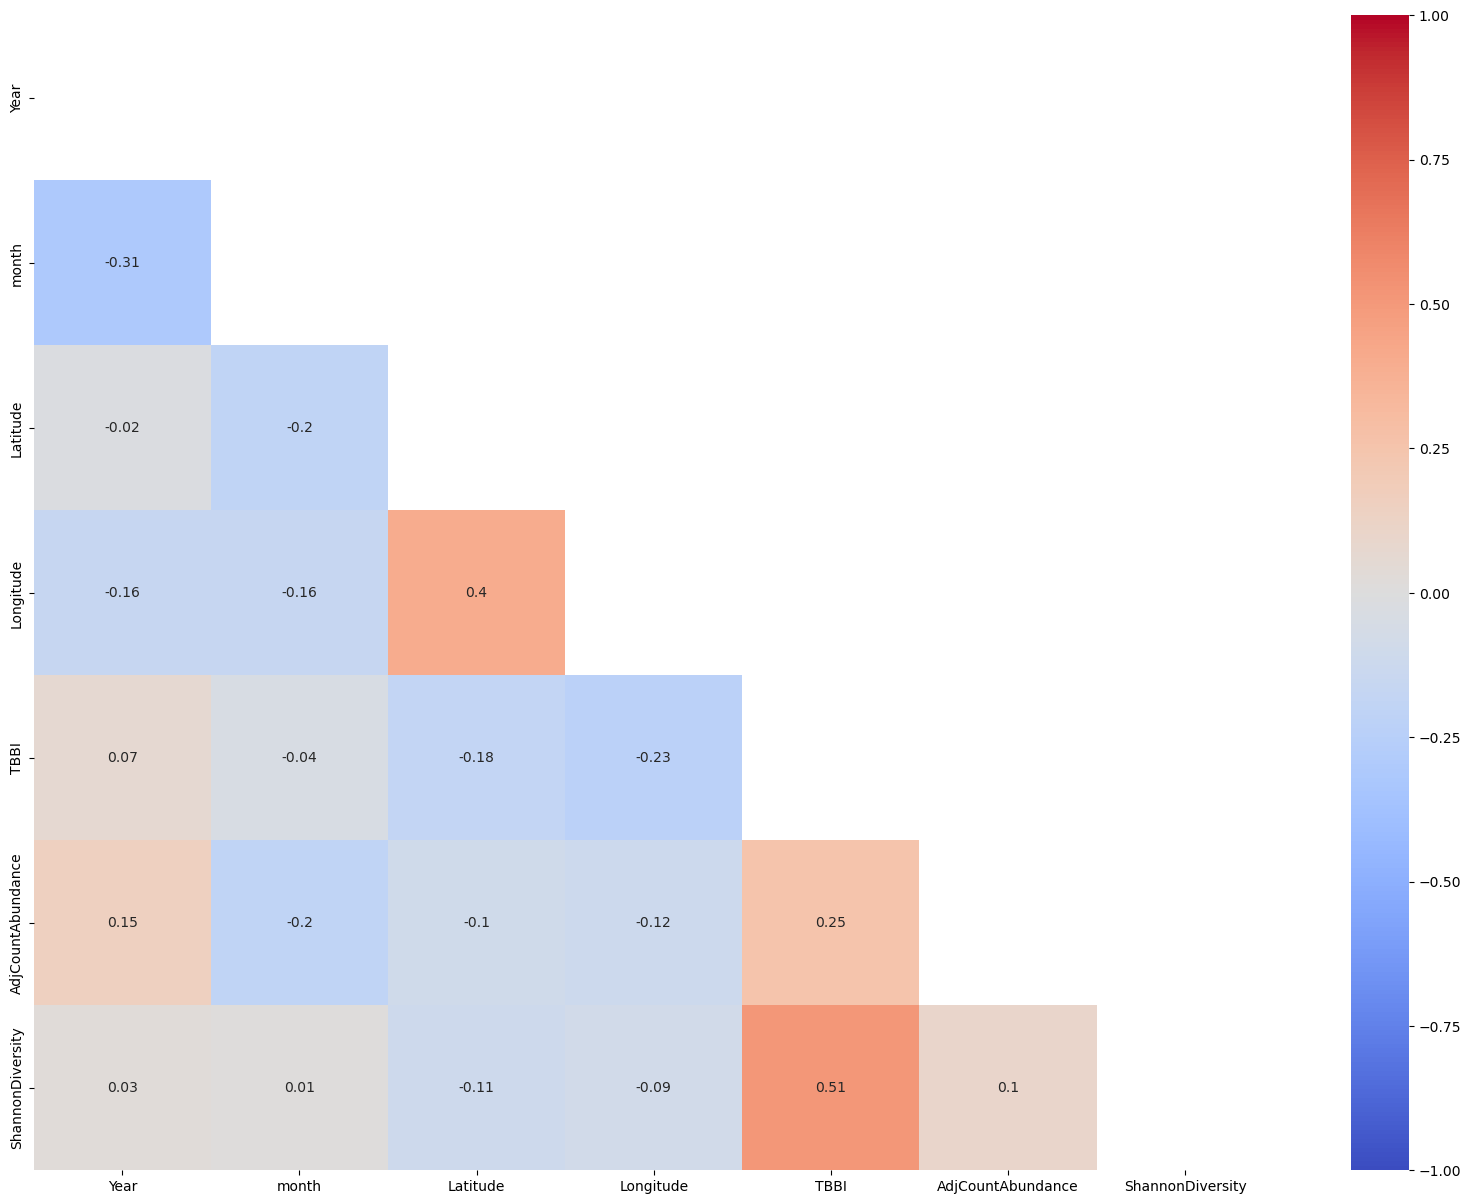

In [298]:
corr=benthic_corr.corr()
mask=np.triu(corr)
plt.figure(figsize=(20,15))
sns.heatmap(corr.round(2), vmax=1,vmin=-1,center=0,cmap='coolwarm',mask=mask, annot=True)
plt.show

In [311]:
benthic_corr.isna().value_counts()

Year   month  Latitude  Longitude  TBBI   AdjCountAbundance  ShannonDiversity
False  False  False     False      False  False              False               4568
                                   True   True               True                 219
Name: count, dtype: int64

In [315]:
benthic_corr.dropna(inplace=True)

C:\Users\Ajax\AppData\Local\Temp\ipykernel_45136\4009152946.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [404]:
benthic_corr.shape

(4568, 7)

<Axes: xlabel='Year', ylabel='ShannonDiversity'>

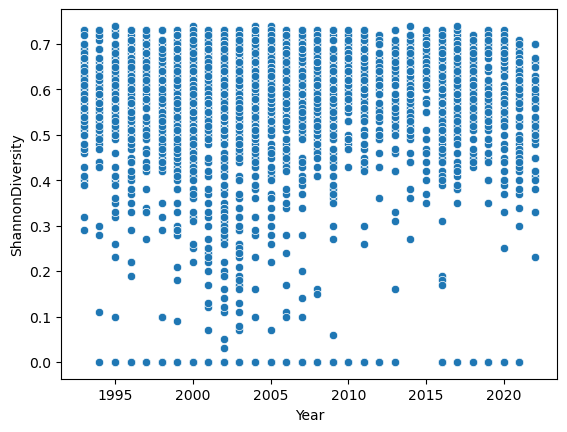

In [412]:
sns.scatterplot(x=benthic_corr.Year,y=benthic_corr.ShannonDiversity)

<Axes: xlabel='AdjCountAbundance', ylabel='ShannonDiversity'>

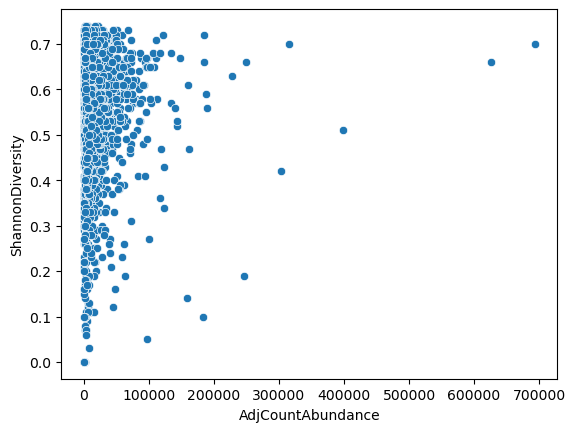

In [409]:
sns.scatterplot(x=benthic_corr.AdjCountAbundance,y=benthic_corr.ShannonDiversity)

In [ ]:
benthic_corr.drop(columns='ShannonDiversity')

In [447]:
X_train, X_test, y_train, y_test = train_test_split(benthic_corr.drop(columns='ShannonDiversity'), benthic_corr.ShannonDiversity, test_size=0.2, random_state=42)

In [414]:
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [415]:
LinReg_benthic=LinearRegression()
LinReg_benthic.fit(X_train,y_train)

LinearRegression()

In [416]:
LinReg_benthic.score(X_train,y_train)

0.27743599677647934

In [417]:
LinReg_benthic.score(X_test,y_test)

0.23174778627122627

In [418]:
# L1
myLasso_benthic=Lasso()
# L2
myRidge_benthic=Ridge()

In [419]:
myLasso_benthic.fit(X_train,y_train)

Lasso()

In [420]:
myRidge_benthic.fit(X_train,y_train)

Ridge()

In [421]:
print(f"The testing R^2 of Lasso Regression is: {myLasso_benthic.score(X_test, y_test)}")
print(f"The testing R^2 of Ridge Regression is: {myRidge_benthic.score(X_test, y_test)}")

The testing R^2 of Lasso Regression is: -2.128567856529706e-05
The testing R^2 of Ridge Regression is: 0.23175341463056698


In [433]:
from sklearn.feature_selection import f_regression #evalution metric, because we are predicting a continuous variable

In [453]:
benthic_corr.feature_names

AttributeError: 'DataFrame' object has no attribute 'feature_names'

In [428]:
myRidge_benthic.coef_

array([ 0.00350142,  0.00473842, -0.00641467,  0.00807598,  0.10270951,
       -0.00634674])

In [456]:
train_scores = []
test_scores = []

#find values of K (number of features) to loop through!
ks = [1,2,3,4,5,6]

for k in ks:
    #instantiate the KBest model
    model = SelectKBest(f_regression, k = k).fit(X_train, y_train)
    X_train_selected = model.transform(X_train) #this step reduces the number of features in X_train
    X_test_selected = model.transform(X_test)

    LR = LinearRegression()
    LR.fit(X_train_selected, y_train)

    #let's print out which exact features are left in the model at each value of K!
    print(f"K = {k}, {np.array(benthic_corr.drop(columns='ShannonDiversity').columns)[model.get_support()]}")

    train_scores.append(LR.score(X_train_selected, y_train))
    test_scores.append(LR.score(X_test_selected, y_test))

K = 1, ['TBBI']
K = 2, ['Latitude' 'TBBI']
K = 3, ['Latitude' 'TBBI' 'AdjCountAbundance']
K = 4, ['Latitude' 'Longitude' 'TBBI' 'AdjCountAbundance']
K = 5, ['Year' 'Latitude' 'Longitude' 'TBBI' 'AdjCountAbundance']
K = 6, ['Year' 'month' 'Latitude' 'Longitude' 'TBBI' 'AdjCountAbundance']


In [457]:
train_scores

[0.27402615327668345,
 0.27443099196776366,
 0.2757454952083416,
 0.27683022939336077,
 0.2769316260293224,
 0.27743599677647945]

Year


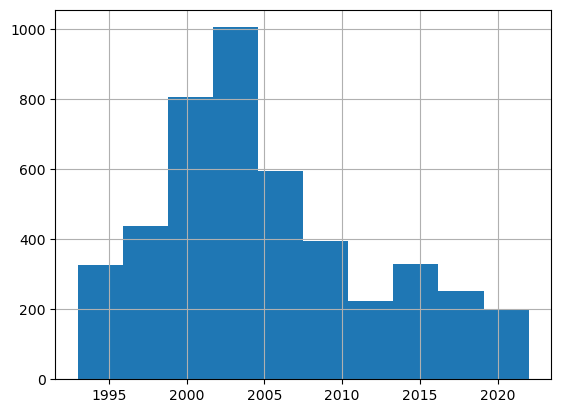

month


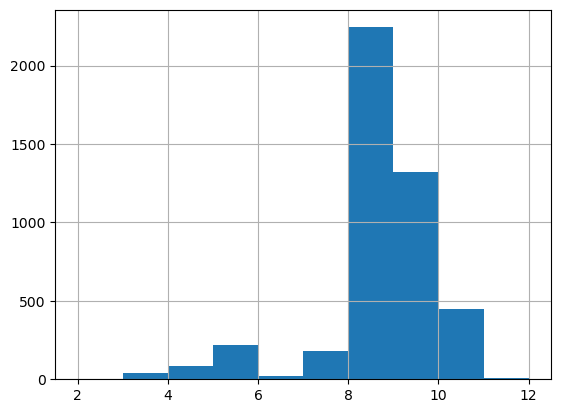

Latitude


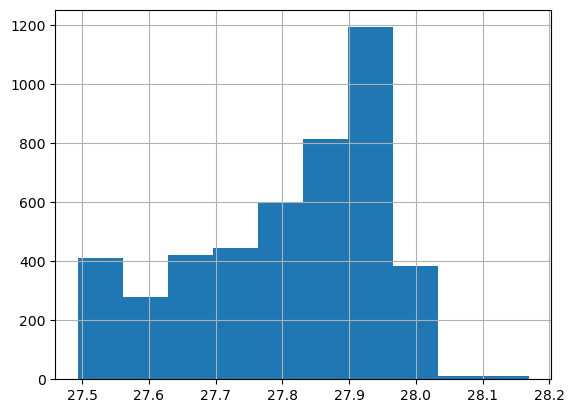

Longitude


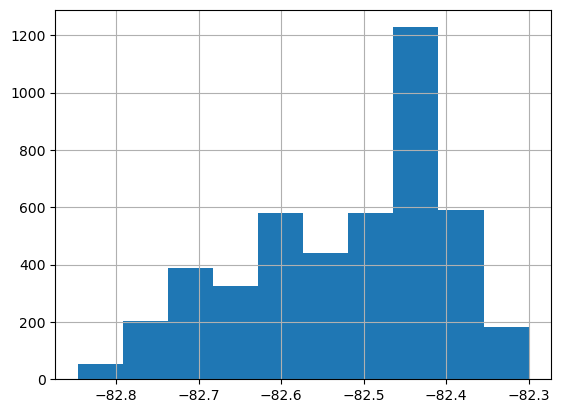

TBBI


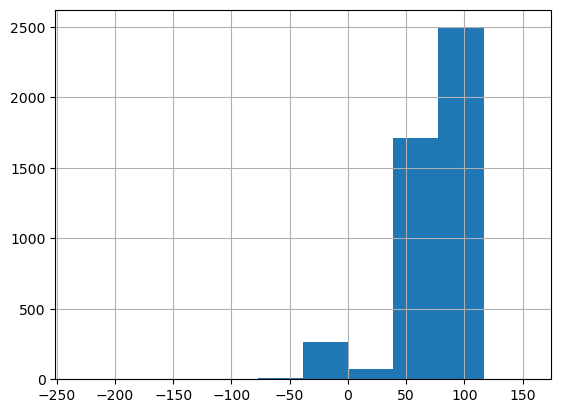

AdjCountAbundance


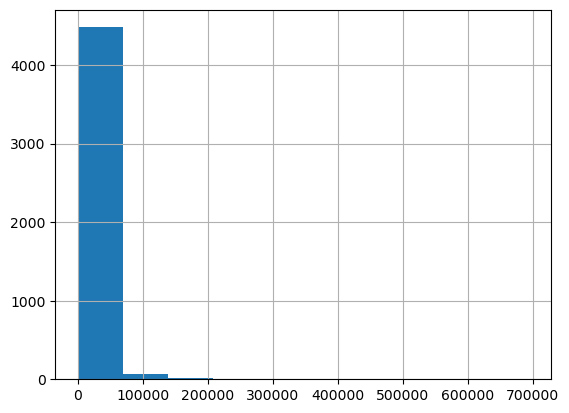

ShannonDiversity


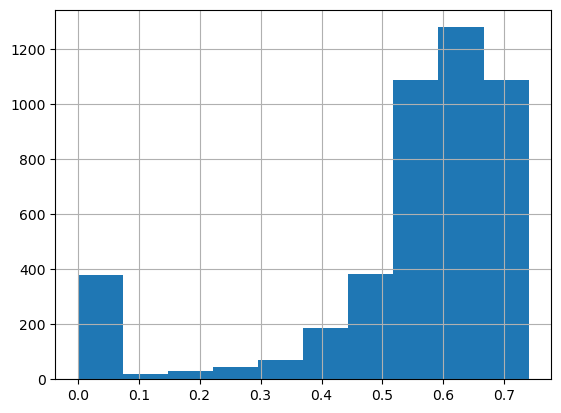

In [462]:
for i in benthic_corr.columns:
    print(i)
    benthic_corr[i].hist()
    plt.show()

In [436]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

#### Population and Development

In [ ]:
os.chdir()

##### Scrap

In [ ]:
####

In [446]:
X_train

array([[-0.8557209 , -0.12540009,  0.37388503,  1.495652  , -0.21221512,
         0.42185753],
       [-0.43857266, -0.12540009,  0.34884805,  1.37670453,  0.41497193,
         0.36505767],
       [ 0.25667441, -0.12540009,  0.94515023,  1.15707586,  0.04008854,
        -0.43711568],
       ...,
       [ 0.25667441, -0.12540009,  1.10595408, -0.26803601,  0.50145455,
        -0.24080742],
       [ 1.09097089, -0.12540009,  0.40811378, -0.74322055,  0.73796574,
         0.62414472],
       [-0.8557209 ,  1.39943166,  0.02225369,  0.44186956,  0.36233033,
        -0.25276528]])

In [ ]:
f_regression_b=f_regression(X_train.AdjCountAbundance,y_train)

In [ ]:
SelectKBest(f_regression_b,k=k).fit(X_train[0],y_train)

In [444]:
X_train[0]

array([-0.8557209 , -0.12540009,  0.37388503,  1.495652  , -0.21221512,
        0.42185753])